In [ ]:
df=pd.read_csv(r"E:\PROJECT\Maternal\ml_model\dataset\preprocessed Maternal Health Risk.csv")

NameError: name 'pd' is not defined

In [ ]:
df

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,1
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,0
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,0
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,0
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1182,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,1
1183,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,1
1184,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,1
1185,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


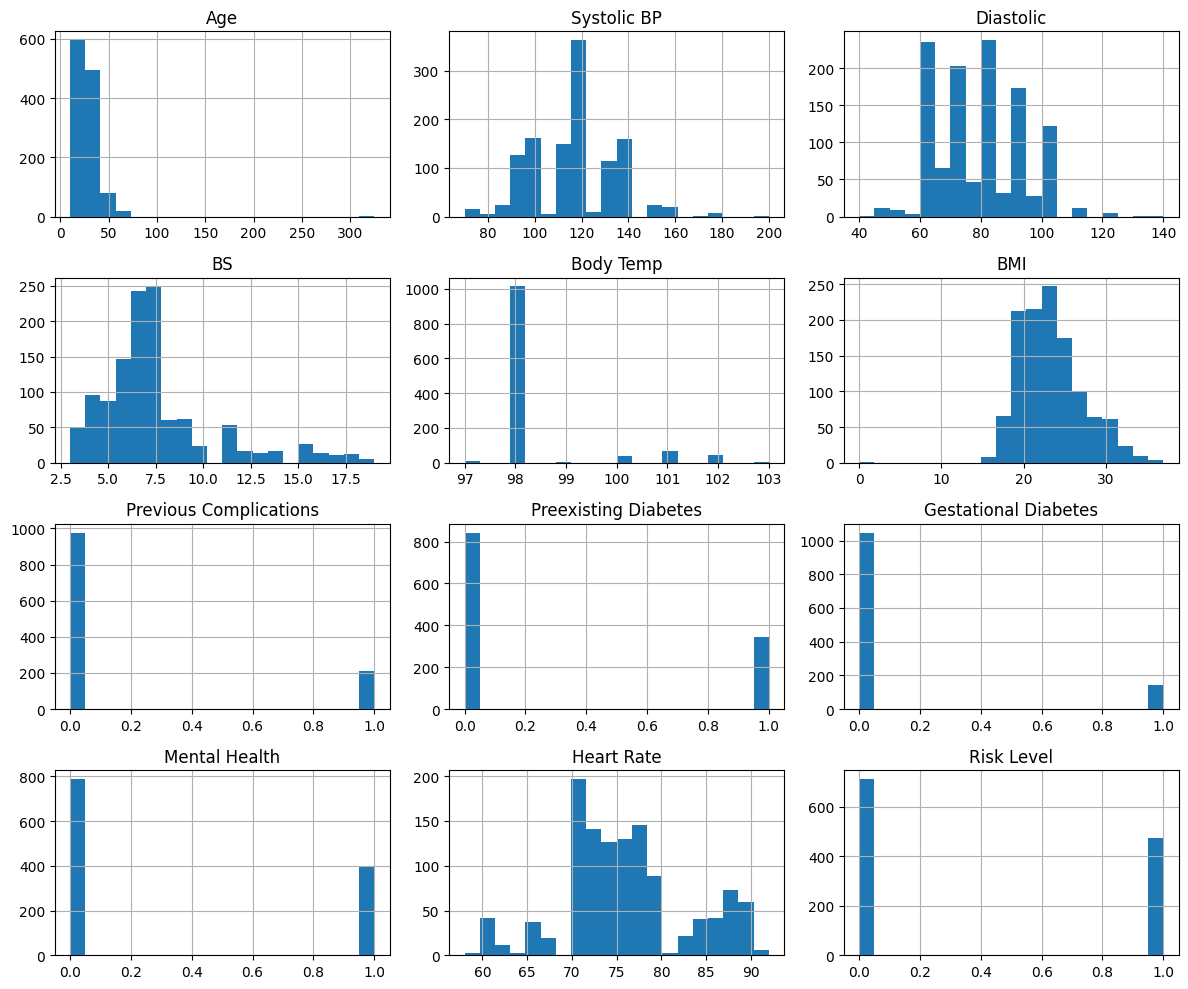

In [ ]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()


In [ ]:
corr_matrix = df.corr()


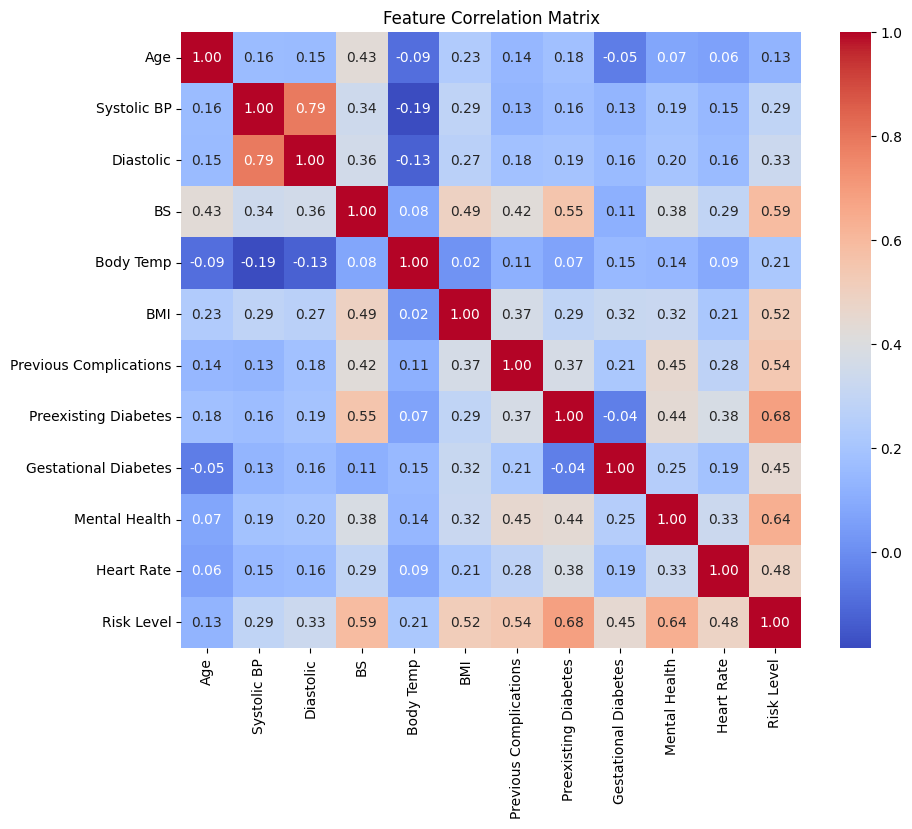

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


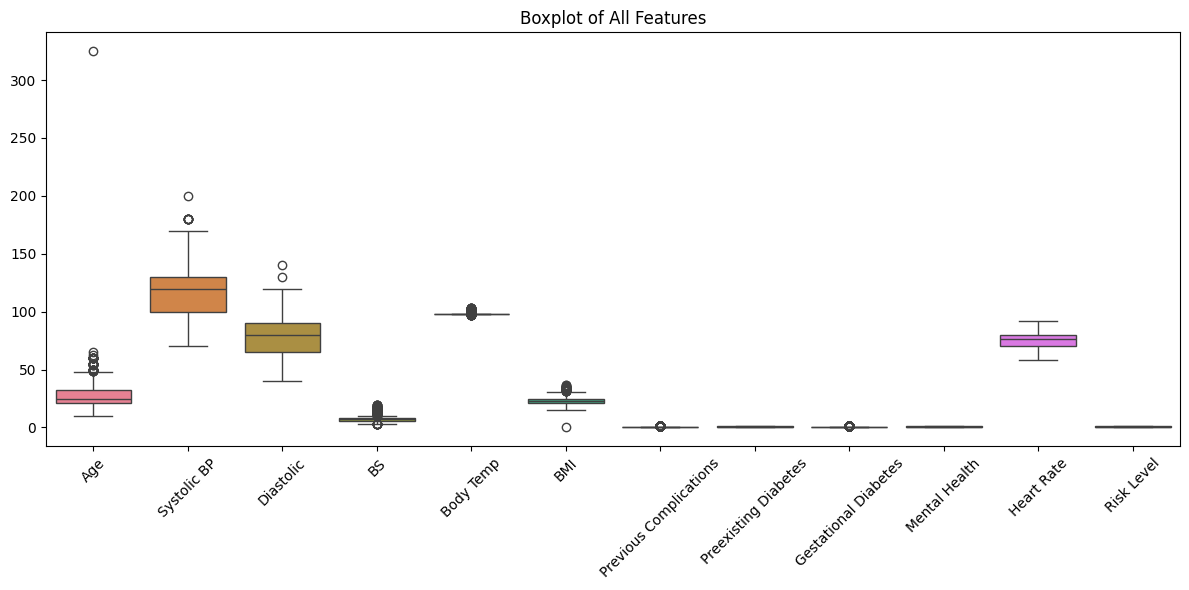

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of All Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

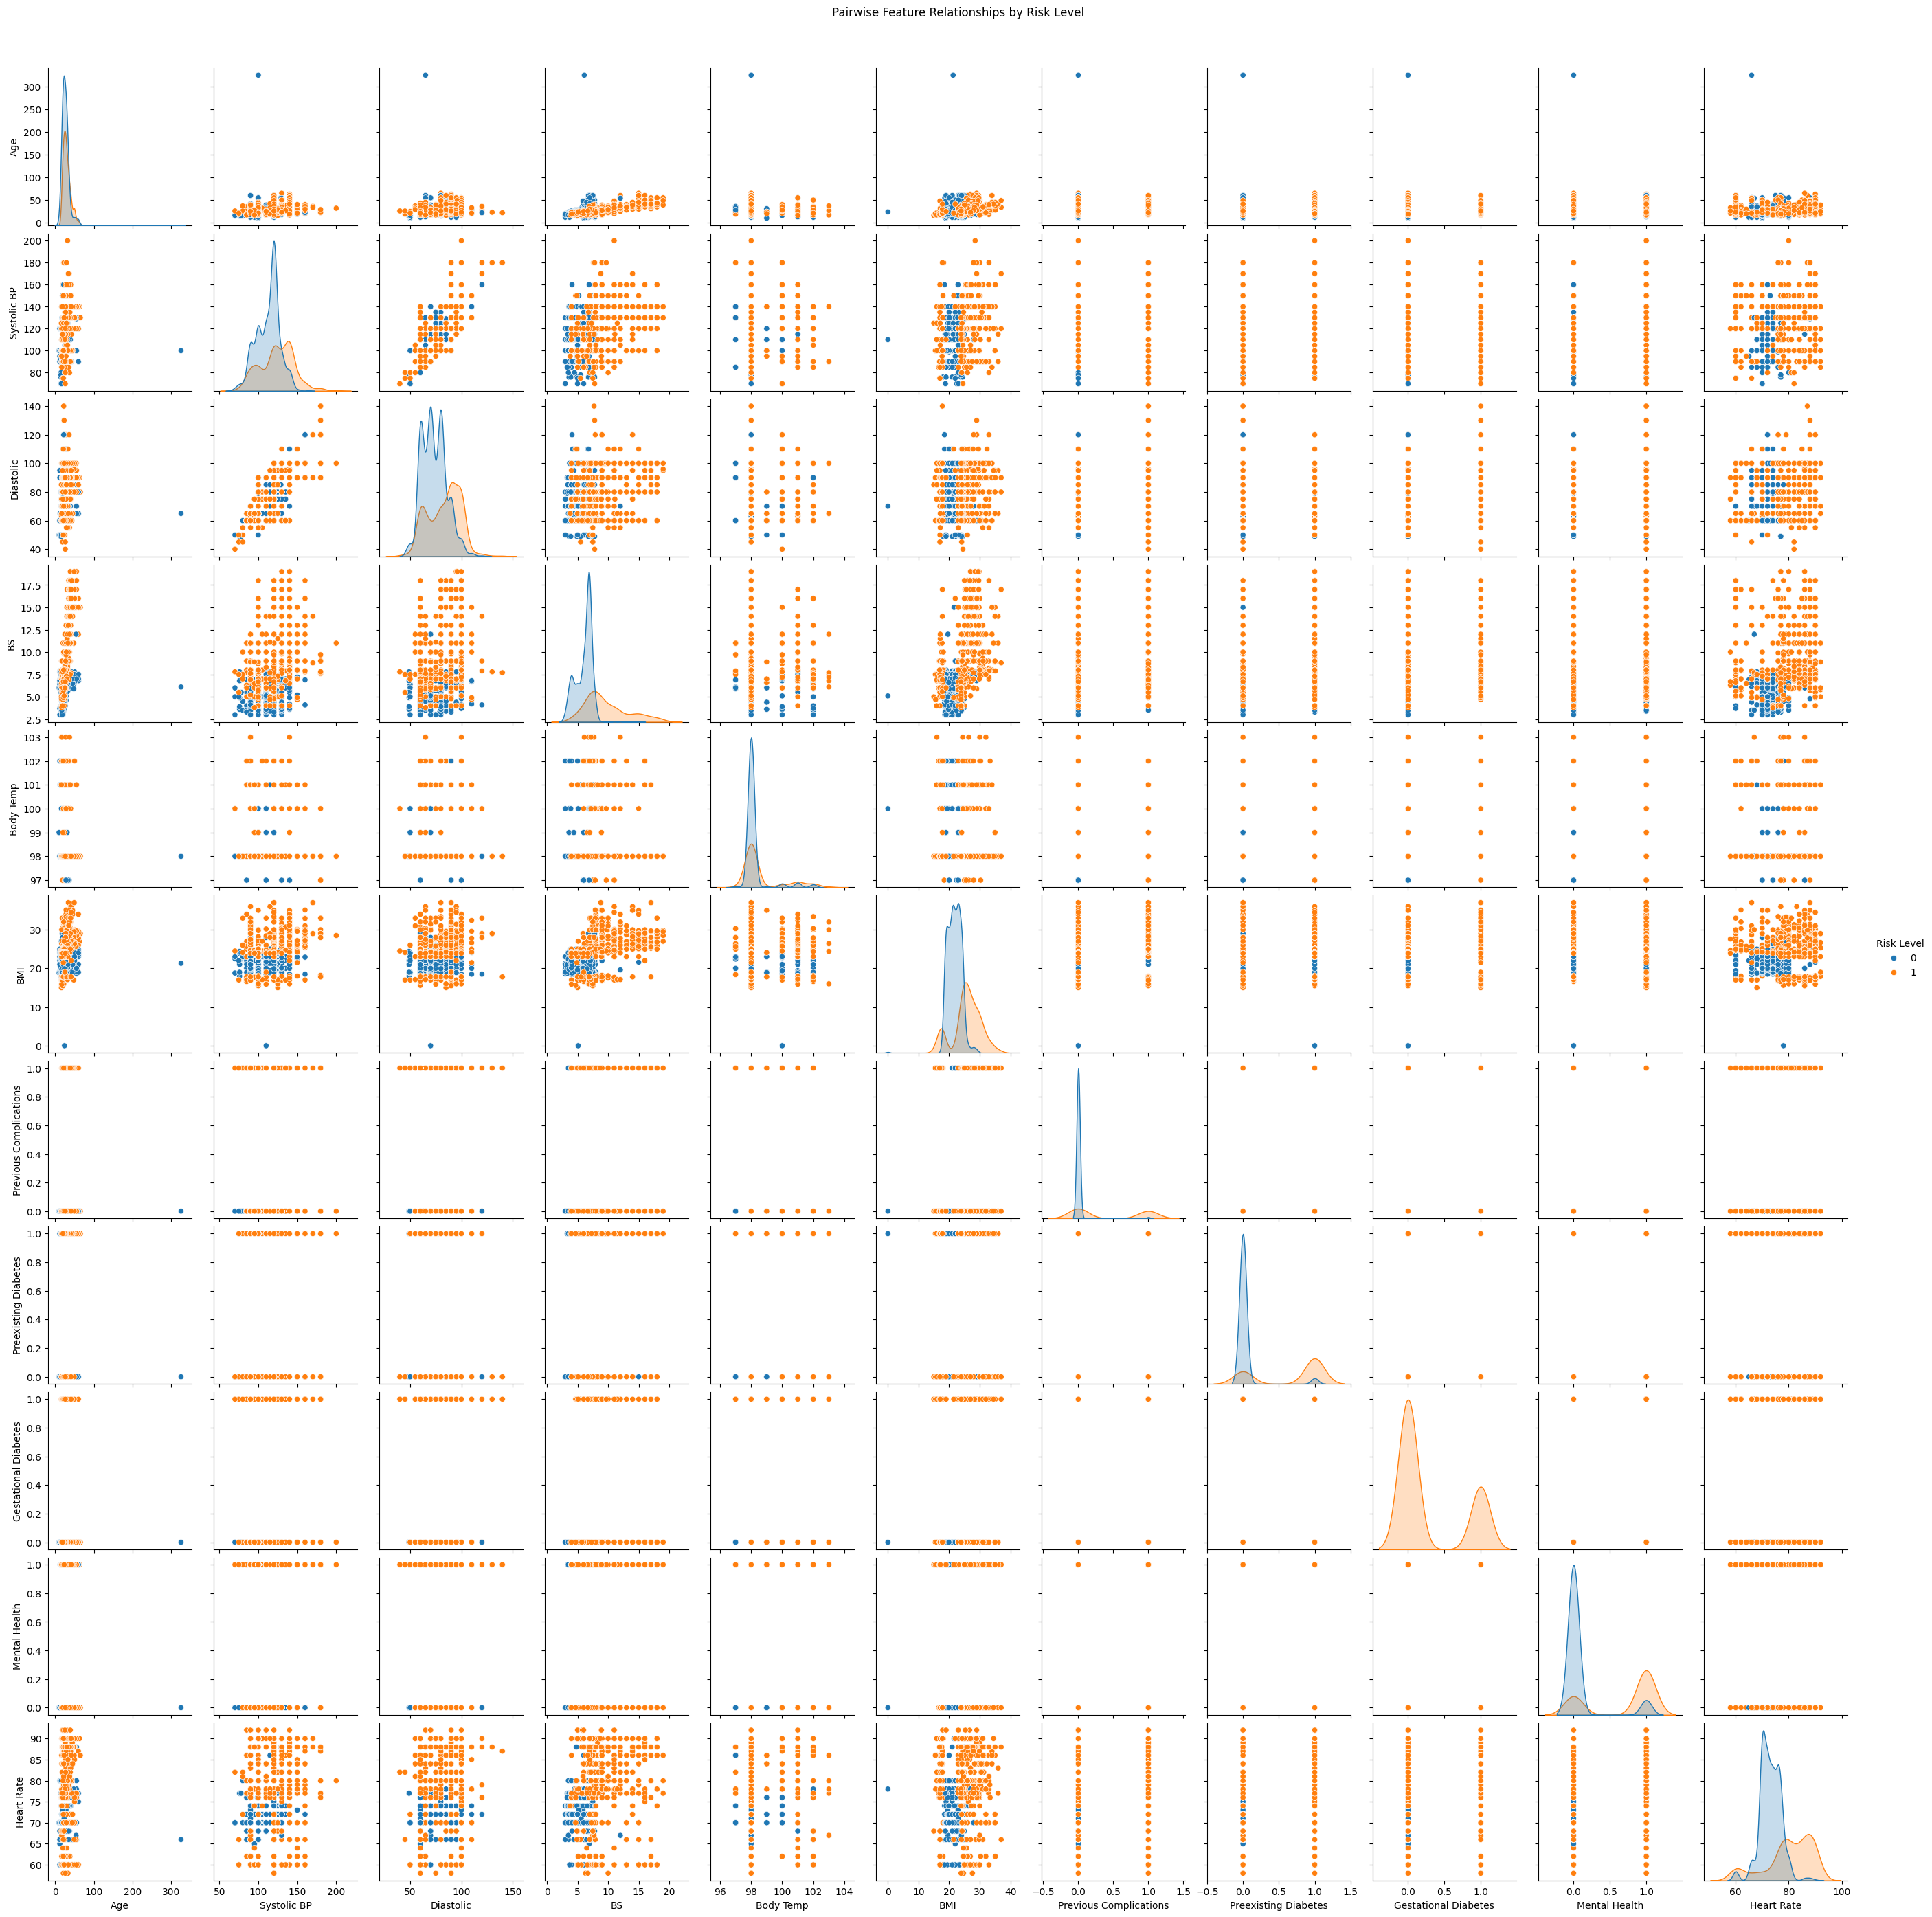

In [ ]:
sns.pairplot(df, hue='Risk Level', diag_kind='kde')
plt.suptitle("Pairwise Feature Relationships by Risk Level", y=1.02)
plt.show()


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1187.0,27.764111,12.645309,10.0,21.0,25.0,32.00,325.0
Systolic BP,1187.0,116.851727,18.664290,70.0,100.0,120.0,130.00,200.0
Diastolic,1187.0,77.213142,14.262744,40.0,65.0,80.0,90.00,140.0
BS,1187.0,7.515906,3.051976,3.0,6.0,6.9,7.95,19.0
Body Temp,1187.0,98.396799,1.089621,97.0,98.0,98.0,98.00,103.0
BMI,1187.0,23.335805,3.860819,0.0,21.0,23.0,25.00,37.0
Previous Complications,1187.0,0.176917,0.381759,0.0,0.0,0.0,0.00,1.0
Preexisting Diabetes,1187.0,0.289806,0.453864,0.0,0.0,0.0,1.00,1.0
Gestational Diabetes,1187.0,0.117944,0.322678,0.0,0.0,0.0,0.00,1.0
Mental Health,1187.0,0.335299,0.472294,0.0,0.0,0.0,1.00,1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier



In [ ]:
X = df.drop('Risk Level', axis=1)
y = df['Risk Level']



In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X, y)



RandomForestClassifier(random_state=42)

In [ ]:
importances = model.feature_importances_
features = X.columns


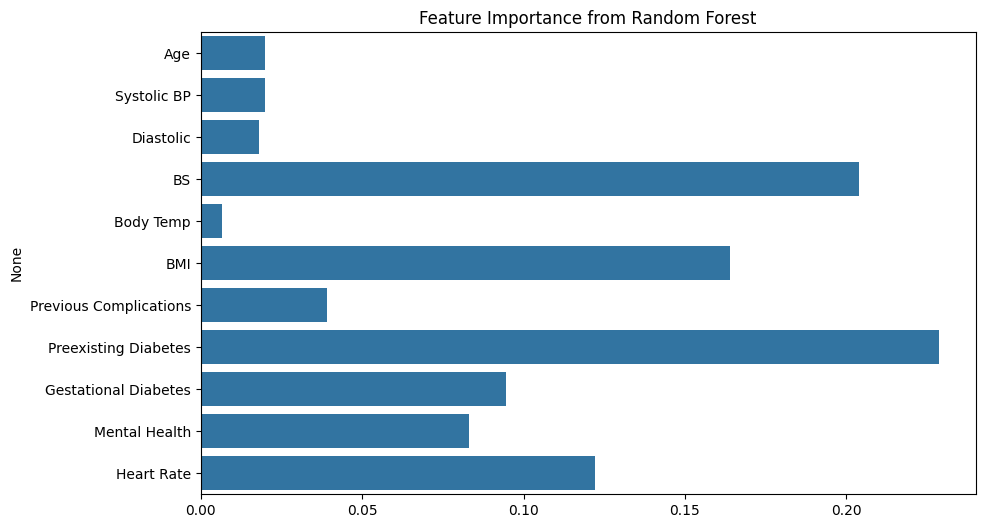

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance from Random Forest")
plt.show()


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler



In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)



In [ ]:
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_scaled, y)


SelectKBest(k='all', score_func=<function chi2 at 0x00000239607D7880>)

In [ ]:
chi_scores = chi_selector.scores_
chi_pvalues = chi_selector.pvalues_
features = X.columns



In [ ]:
chi_df = pd.DataFrame({
    'Feature': features,
    'Chi2 Score': chi_scores,
    'p-value': chi_pvalues
}).sort_values(by='Chi2 Score', ascending=False)


In [ ]:
print("\nChi-squared Feature Ranking:")
print(chi_df.reset_index(drop=True))



Chi-squared Feature Ranking:
                   Feature  Chi2 Score       p-value
0     Preexisting Diabetes  395.424669  5.456836e-88
1            Mental Health  321.044491  8.578071e-72
2   Previous Complications  286.550132  2.807157e-64
3     Gestational Diabetes  210.590717  1.020913e-47
4                       BS   53.455980  2.644527e-13
5               Heart Rate   23.910766  1.009059e-06
6                Body Temp    7.628409  5.745597e-03
7                Diastolic    7.168621  7.418977e-03
8              Systolic BP    5.730122  1.667633e-02
9                      BMI    5.487107  1.915722e-02
10                     Age    0.544985  4.603740e-01


In [ ]:
from scipy.stats import spearmanr



In [ ]:
features = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']
spearman_results = []


In [ ]:
for feature in features:
    coef, p = spearmanr(df[feature], df['Risk Level'])
    spearman_results.append((feature, round(coef, 2), round(p, 4)))


In [ ]:
for result in spearman_results:
    print(f"{result[0]}: Spearman Coefficient = {result[1]}, p-value = {result[2]}")


Age: Spearman Coefficient = 0.2, p-value = 0.0
Systolic BP: Spearman Coefficient = 0.29, p-value = 0.0
Diastolic: Spearman Coefficient = 0.32, p-value = 0.0
BS: Spearman Coefficient = 0.62, p-value = 0.0
Body Temp: Spearman Coefficient = 0.2, p-value = 0.0
BMI: Spearman Coefficient = 0.54, p-value = 0.0
Heart Rate: Spearman Coefficient = 0.52, p-value = 0.0


In [ ]:
class_counts = df["Risk Level"].value_counts()
print("Class Distribution:\n", class_counts)



Class Distribution:
 Risk Level
0    713
1    474
Name: count, dtype: int64


In [ ]:
X.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0


In [ ]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: Risk Level, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
298,34,130.0,90.0,6.6,98,24.9,0.0,1.0,0,0,74.0
711,60,120.0,85.0,15.0,98,27.8,0.0,1.0,0,1,60.0
654,21,90.0,60.0,6.9,98,23.0,0.0,0.0,0,0,86.0
275,28,110.0,80.0,6.4,98,24.4,0.0,0.0,0,0,74.0
599,20,120.0,75.0,6.8,98,22.0,0.0,0.0,0,0,70.0
...,...,...,...,...,...,...,...,...,...,...,...
1044,17,110.0,75.0,4.0,101,15.9,0.0,1.0,0,1,90.0
1095,20,100.0,60.0,7.0,99,24.1,0.0,1.0,0,1,84.0
1130,27,135.0,60.0,6.8,98,24.7,1.0,1.0,0,1,60.0
860,17,90.0,65.0,6.1,103,26.4,0.0,0.0,0,1,77.0


In [ ]:
y_train

298     0
711     1
654     0
275     0
599     0
       ..
1044    1
1095    1
1130    1
860     1
1126    1
Name: Risk Level, Length: 949, dtype: int64

In [ ]:
X_test

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
319,25,80.0,60.0,4.5,98,23.0,0.0,0.0,0,0,70.0
956,33,130.0,110.0,12.0,100,27.8,0.0,1.0,0,1,88.0
1096,17,110.0,70.0,6.5,98,24.1,0.0,1.0,0,1,84.0
86,30,110.0,70.0,7.4,98,28.0,0.0,0.0,0,0,70.0
990,24,95.0,65.0,6.6,99,17.8,1.0,1.0,0,1,78.0
...,...,...,...,...,...,...,...,...,...,...,...
1043,20,120.0,90.0,4.8,98,23.0,0.0,1.0,0,1,77.0
993,16,125.0,85.0,5.0,98,15.0,0.0,0.0,1,1,68.0
224,22,110.0,70.0,4.4,98,20.0,0.0,0.0,0,0,76.0
724,21,120.0,80.0,7.5,98,20.0,0.0,0.0,0,0,77.0


In [ ]:
y_test

319     0
956     1
1096    1
86      0
990     1
       ..
1043    1
993     1
224     0
724     0
965     0
Name: Risk Level, Length: 238, dtype: int64

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train_scaled

array([[ 0.47176472,  0.71826401,  0.91636687, ..., -0.36208903,
        -0.70319854, -0.24382918],
       [ 2.44269646,  0.17886973,  0.56368938, ..., -0.36208903,
         1.42207348, -2.15504716],
       [-0.51370114, -1.43931308, -1.19969808, ..., -0.36208903,
        -0.70319854,  1.39435766],
       ...,
       [-0.05887074,  0.98796114, -1.19969808, ..., -0.36208903,
         1.42207348, -2.15504716],
       [-0.81692141, -1.43931308, -0.84702059, ..., -0.36208903,
         1.42207348,  0.16571753],
       [-0.05887074, -0.0908274 , -0.14166561, ..., -0.36208903,
         1.42207348,  0.16571753]], shape=(949, 11))

In [ ]:
X_test_scaled

array([[-0.21048088, -1.97870736, -1.19969808, ..., -0.36208903,
        -0.70319854, -0.78989146],
       [ 0.39595966,  0.71826401,  2.32707684, ..., -0.36208903,
         1.42207348,  1.6673888 ],
       [-0.81692141, -0.36052454, -0.4943431 , ..., -0.36208903,
         1.42207348,  1.12132652],
       ...,
       [-0.43789608, -0.36052454, -0.4943431 , ..., -0.36208903,
        -0.70319854,  0.02920196],
       [-0.51370114,  0.17886973,  0.21101189, ..., -0.36208903,
        -0.70319854,  0.16571753],
       [ 0.01693432,  0.17886973,  0.21101189, ..., -0.36208903,
        -0.70319854, -0.24382918]], shape=(238, 11))

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression


In [ ]:

l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
l1.fit(X_train_scaled, y_train)
selector = SelectFromModel(l1, prefit=True)
X_train_sel = selector.transform(X_train_scaled)
X_test_sel = selector.transform(X_test_scaled)


In [ ]:
selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))


Selected Features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate']


In [ ]:
from sklearn.linear_model import Lasso


In [ ]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)


Lasso(alpha=0.01)

In [ ]:
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)


In [ ]:
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features.tolist())


Selected Features: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate']


In [ ]:
leaderboard = []


In [ ]:
model = LogisticRegression()
model.fit(X_train_selected, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_selected)
y_prob = model.predict_proba(X_test_selected)[:, 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [ ]:
leaderboard.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[0]

{'Model': 'Logistic Regression',
 'Accuracy': 0.9873949579831933,
 'Precision': 0.9896907216494846,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9846153846153847,
 'AUC': np.float64(0.9995626822157435)}

In [ ]:
from sklearn.metrics import roc_curve, auc


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



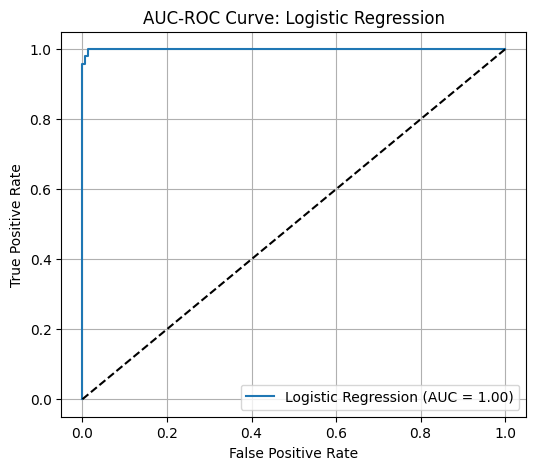

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)



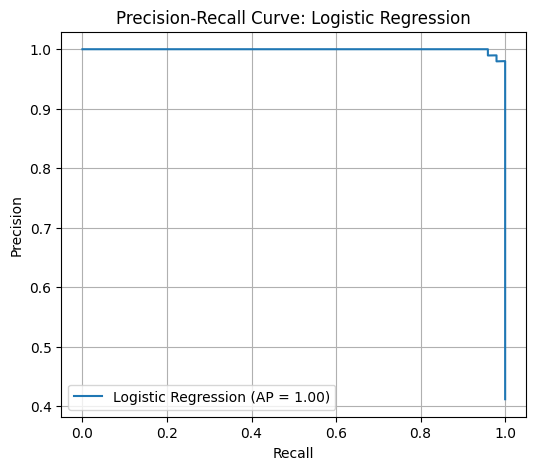

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Logistic Regression (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
df1 = pd.DataFrame({'CV Score': scores, 'Model': ['Logistic Regression']*len(scores)})


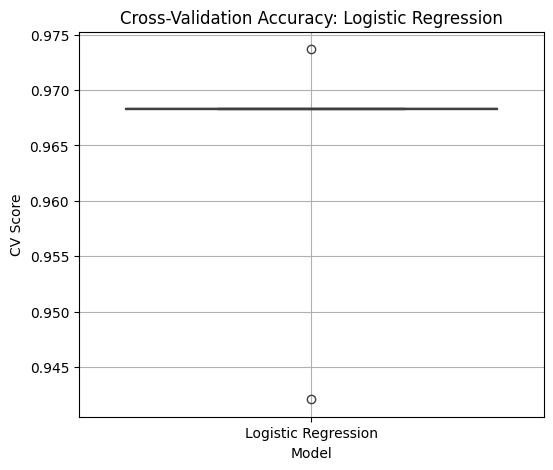

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df1)
plt.title('Cross-Validation Accuracy: Logistic Regression')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import learning_curve


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


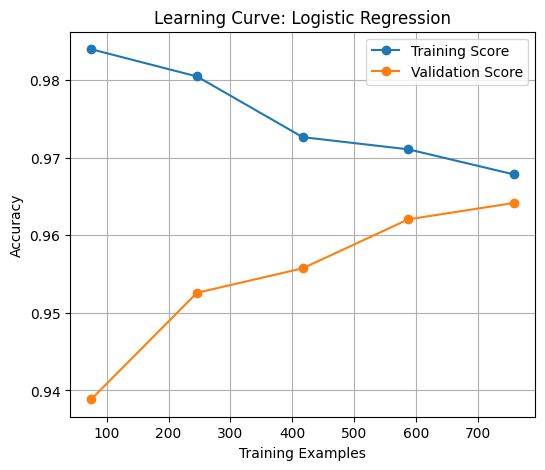

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Logistic Regression')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


In [ ]:
model2 = CalibratedClassifierCV(LinearSVC(penalty='l1', dual=False, random_state=42))
model2.fit(X_train_selected, y_train)


CalibratedClassifierCV(estimator=LinearSVC(dual=False, penalty='l1',
                                           random_state=42))

In [ ]:
y_pred = model2.predict(X_test_selected)
y_prob = model2.predict_proba(X_test_selected)[:, 1]


In [ ]:
leaderboard.append({
    'Model': 'Linear SVM (L1)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[1]

{'Model': 'Linear SVM (L1)',
 'Accuracy': 0.9873949579831933,
 'Precision': 0.9896907216494846,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9846153846153847,
 'AUC': np.float64(0.9995626822157435)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


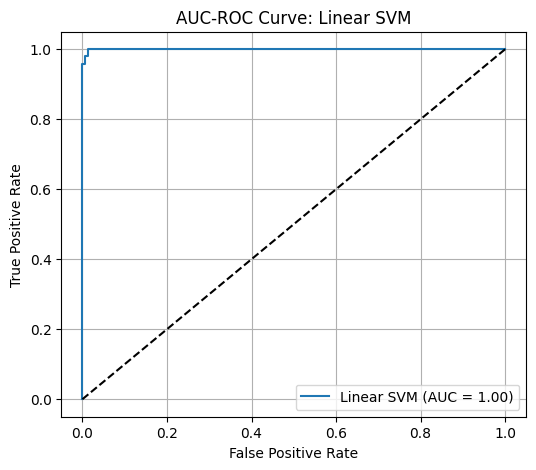

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Linear SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Linear SVM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)




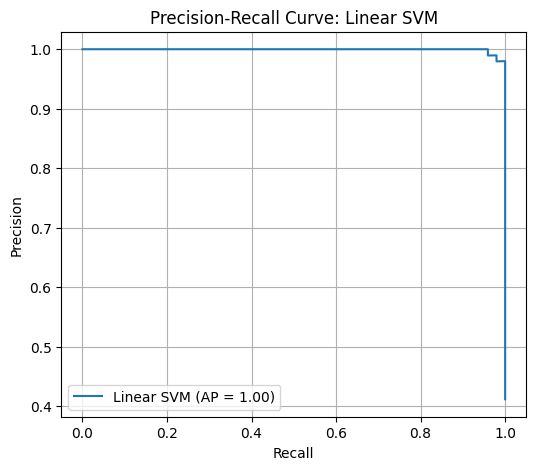

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Linear SVM (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Linear SVM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model2, X_train_selected, y_train, cv=5, scoring='accuracy')
df2 = pd.DataFrame({'CV Score': scores, 'Model': ['Linear SVM']*len(scores)})



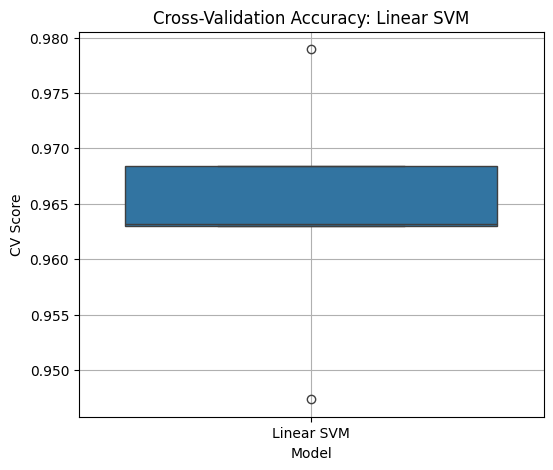

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df2)
plt.title('Cross-Validation Accuracy: Linear SVM')
plt.grid(True)
plt.show()



In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model2, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


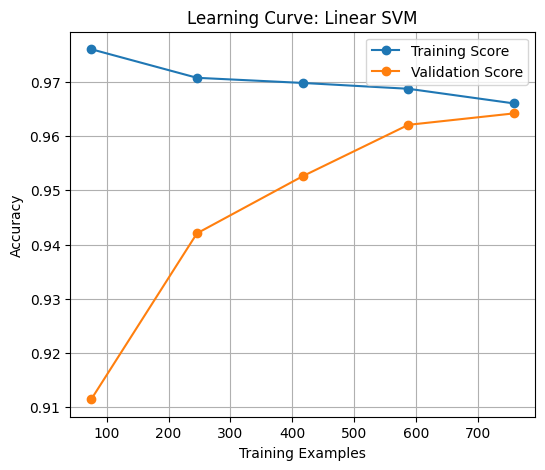

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Linear SVM')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.svm import SVC


In [ ]:
model3 = SVC(kernel='rbf', probability=True)
model3.fit(X_train_selected, y_train)


SVC(probability=True)

In [ ]:
y_pred = model3.predict(X_test_selected)
y_prob = model3.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'RBF SVM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[2]

{'Model': 'RBF SVM',
 'Accuracy': 0.9873949579831933,
 'Precision': 0.9896907216494846,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9846153846153847,
 'AUC': np.float64(0.9994169096209913)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


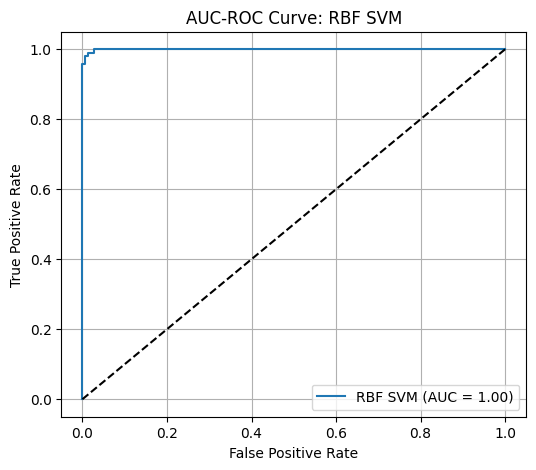

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'RBF SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: RBF SVM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)
avg_precision = average_precision_score(y_test, y_pred)



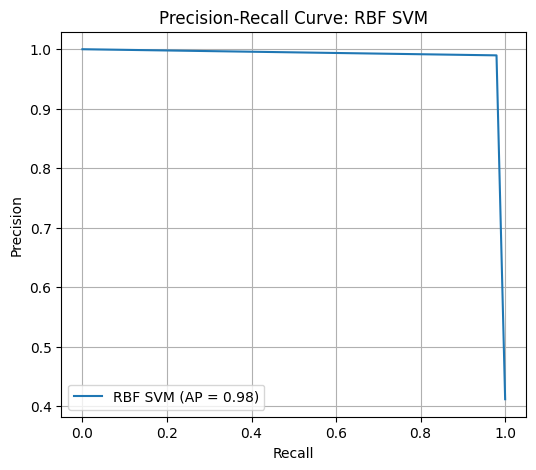

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'RBF SVM (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: RBF SVM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model3, X_train_selected, y_train, cv=5, scoring='accuracy')
df3 = pd.DataFrame({'CV Score': scores, 'Model': ['RBF SVM']*len(scores)})



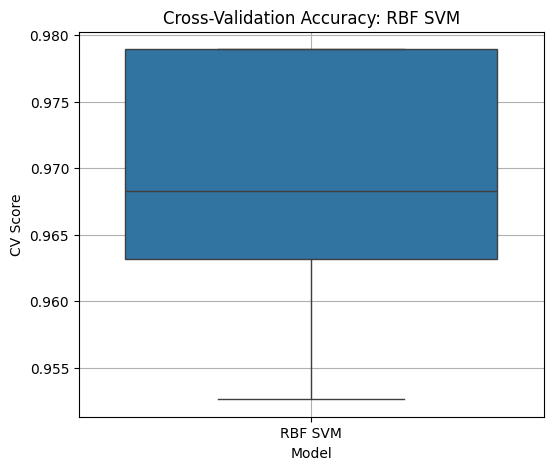

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df3)
plt.title('Cross-Validation Accuracy: RBF SVM')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model3, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)



In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


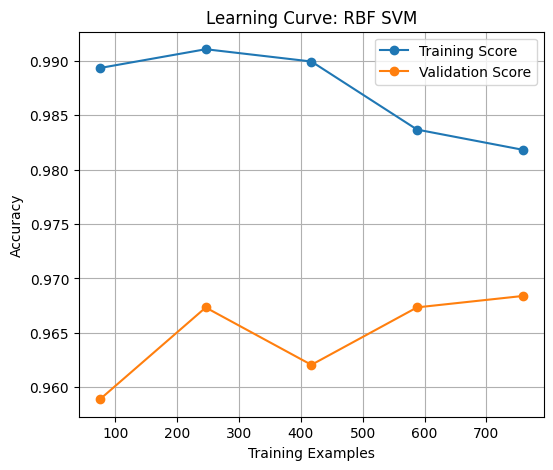

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: RBF SVM')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model4 = DecisionTreeClassifier()
model4.fit(X_train_selected, y_train)


DecisionTreeClassifier()

In [ ]:
y_pred = model4.predict(X_test_selected)
y_prob= model4.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[3]

{'Model': 'Decision Tree',
 'Accuracy': 0.9831932773109243,
 'Precision': 0.9795918367346939,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9795918367346939,
 'AUC': np.float64(0.9826530612244899)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr, tpr)


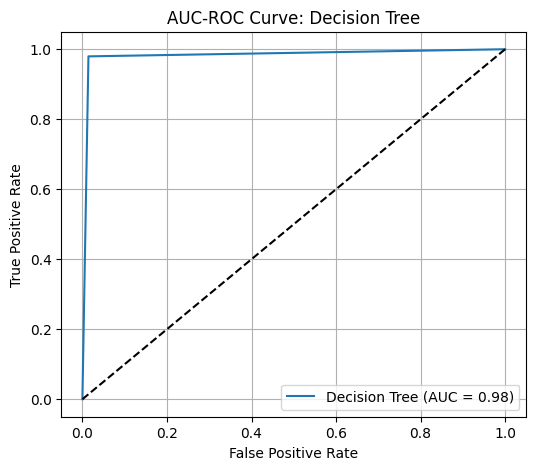

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Decision Tree')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


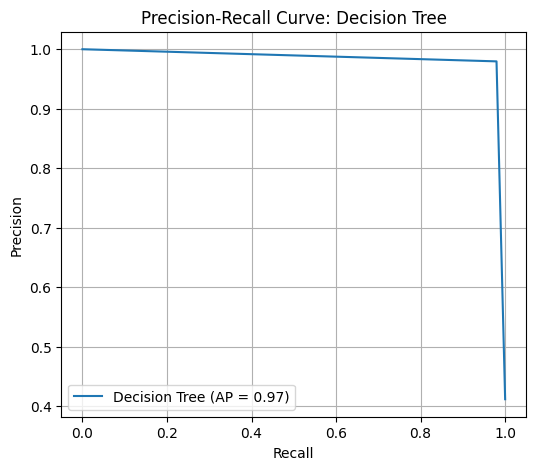

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Decision Tree (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Decision Tree')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model4, X_train_selected, y_train, cv=5, scoring='accuracy')
df4 = pd.DataFrame({'CV Score': scores, 'Model': ['Decision Tree']*len(scores)})


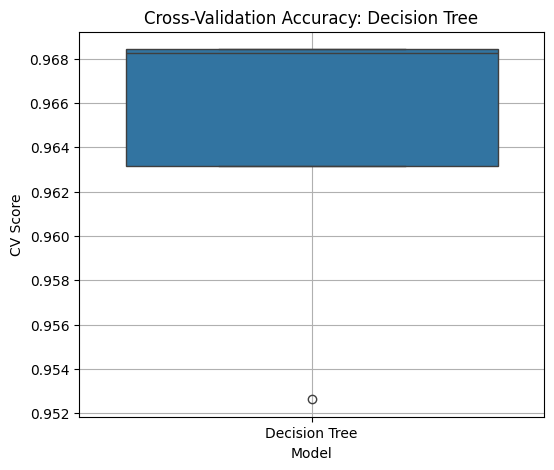

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df4)
plt.title('Cross-Validation Accuracy: Decision Tree')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model4, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


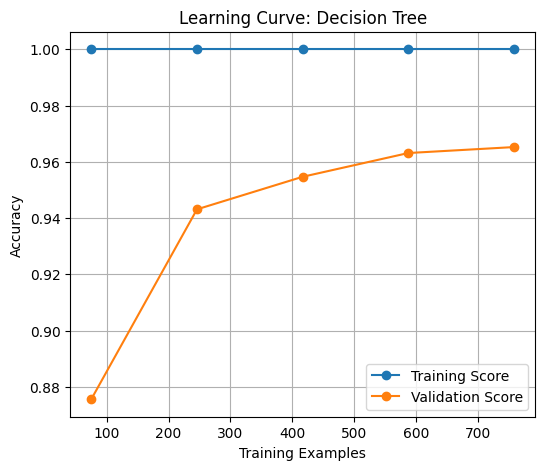

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Decision Tree')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model5 = RandomForestClassifier()
model5.fit(X_train_selected, y_train)


RandomForestClassifier()

In [ ]:
y_pred = model5.predict(X_test_selected)
y_prob = model5.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[4]

{'Model': 'Random Forest',
 'Accuracy': 0.9915966386554622,
 'Precision': 1.0,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9896907216494846,
 'AUC': np.float64(0.9994897959183674)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


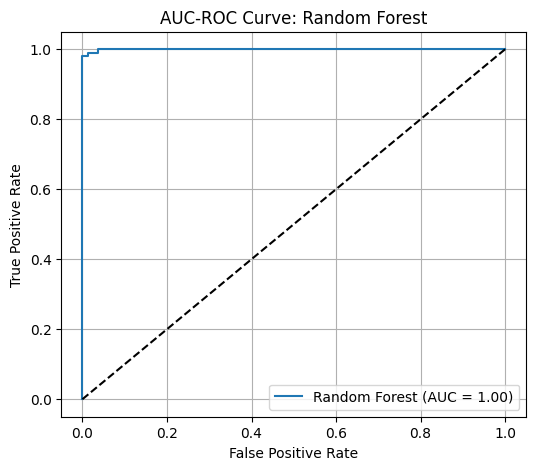

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Random Forest')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


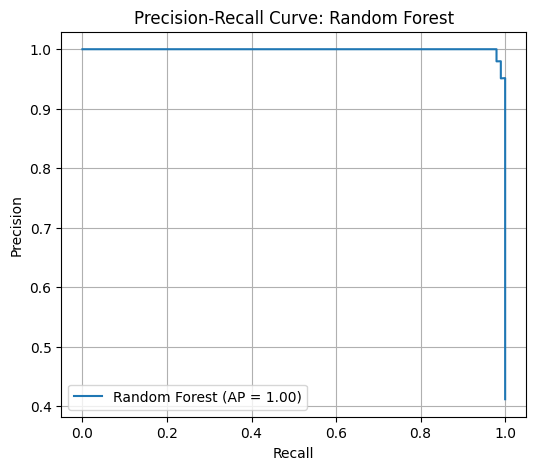

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Random Forest (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Random Forest')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model5, X_train_selected, y_train, cv=5, scoring='accuracy')
df5 = pd.DataFrame({'CV Score': scores, 'Model': ['Random Forest']*len(scores)})



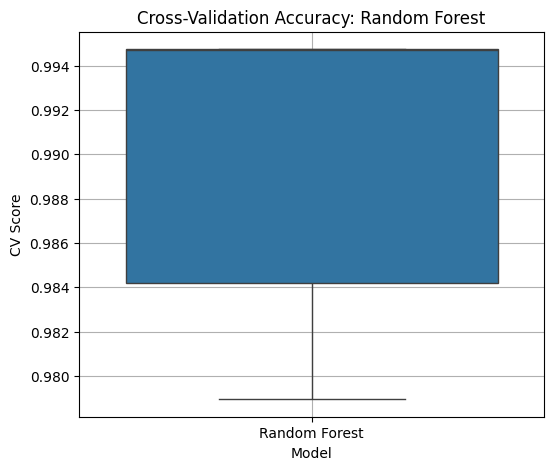

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df5)
plt.title('Cross-Validation Accuracy: Random Forest')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model5, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


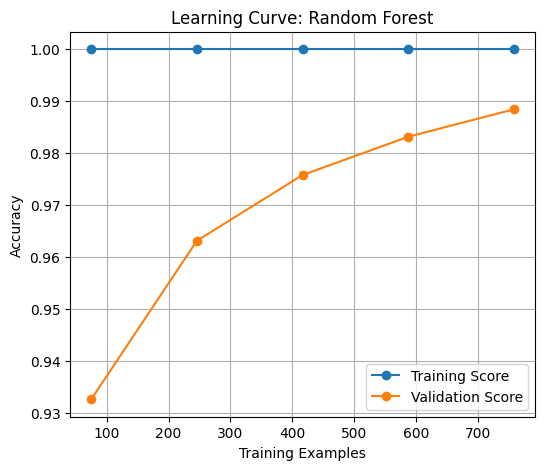

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Random Forest')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from xgboost import XGBClassifier
model6 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model6.fit(X_train_selected, y_train)


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [14:52:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model6.predict(X_test_selected)
y_prob = model6.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[5]

{'Model': 'XGBoost',
 'Accuracy': 0.9915966386554622,
 'Precision': 1.0,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9896907216494846,
 'AUC': np.float64(1.0)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



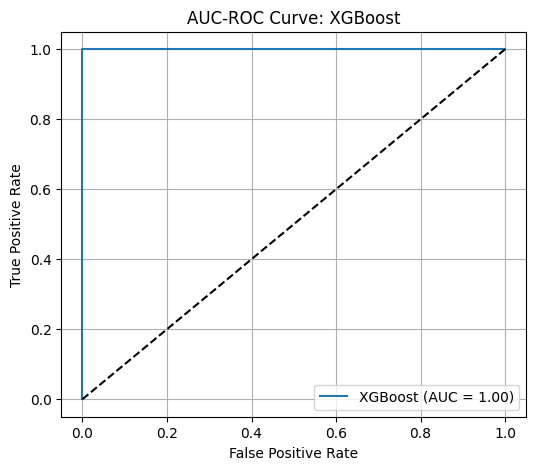

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: XGBoost')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

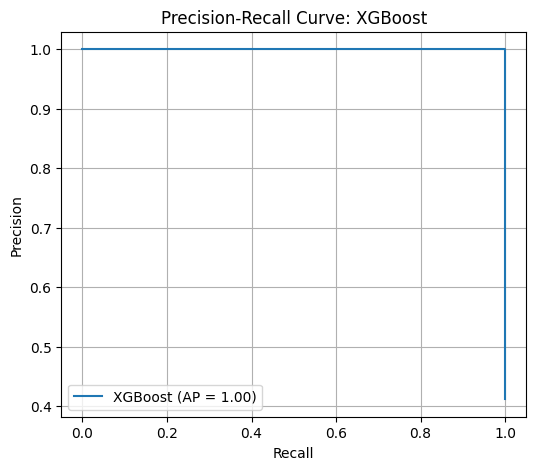

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'XGBoost (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: XGBoost')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model6, X_train_selected, y_train, cv=5, scoring='accuracy')
df6 = pd.DataFrame({'CV Score': scores, 'Model': ['XGBoost']*len(scores)})



C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [14:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [14:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [14:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [14:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:7

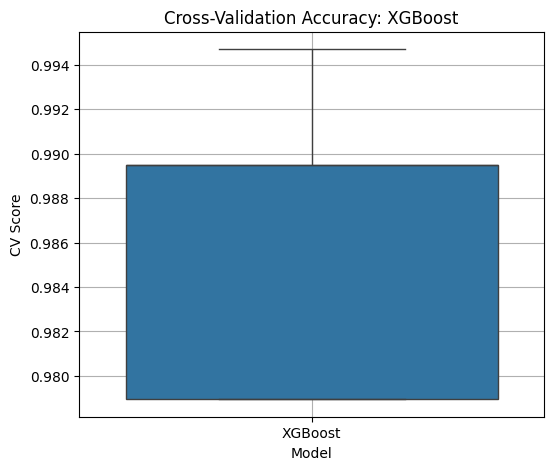

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df6)
plt.title('Cross-Validation Accuracy: XGBoost')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model6, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


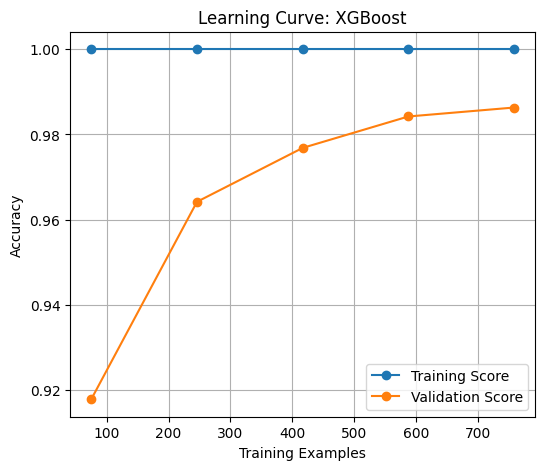

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: XGBoost')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model7 = AdaBoostClassifier()
model7.fit(X_train_selected, y_train)


AdaBoostClassifier()

In [ ]:
y_pred = model7.predict(X_test_selected)
y_prob = model7.predict_proba(X_test_selected)[:, 1]


In [ ]:
leaderboard.append({
    'Model': 'AdaBoost',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[6]

{'Model': 'AdaBoost',
 'Accuracy': 0.9831932773109243,
 'Precision': 0.9895833333333334,
 'Recall': 0.9693877551020408,
 'F1-score': 0.979381443298969,
 'AUC': np.float64(0.9997813411078718)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


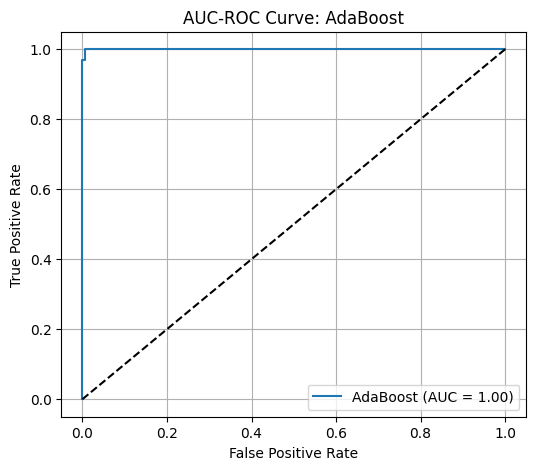

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AdaBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: AdaBoost')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)



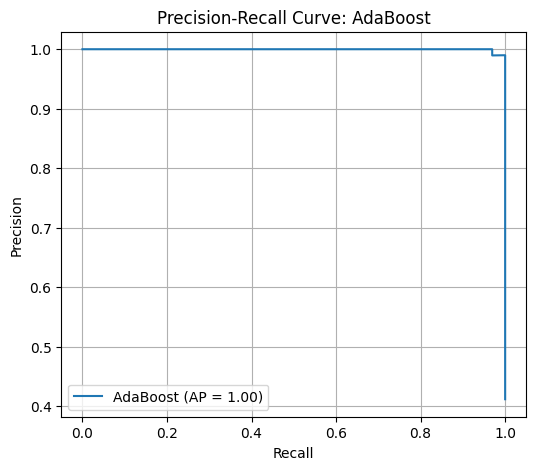

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AdaBoost (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: AdaBoost')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model7, X_train_selected, y_train, cv=5, scoring='accuracy')
df7 = pd.DataFrame({'CV Score': scores, 'Model': ['AdaBoost']*len(scores)})


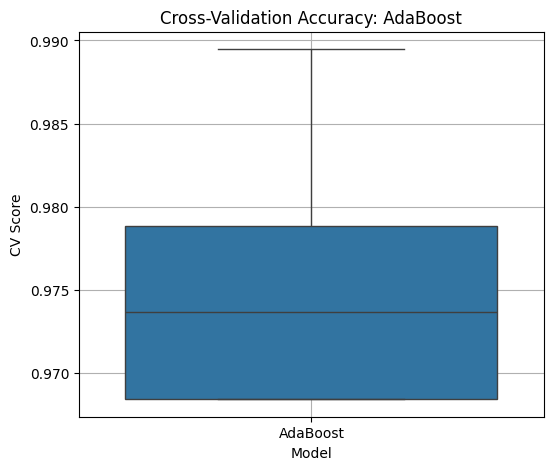

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df7)
plt.title('Cross-Validation Accuracy: AdaBoost')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model7, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)



In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


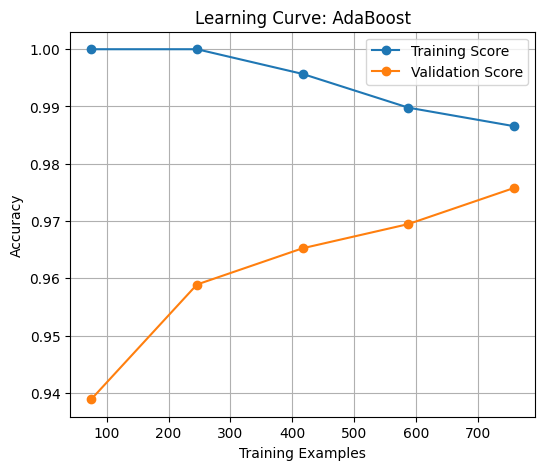

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: AdaBoost')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import BaggingClassifier
model8 = BaggingClassifier()
model8.fit(X_train_selected, y_train)


BaggingClassifier()

In [ ]:
y_pred = model8.predict(X_test_selected)
y_prob=model8.predict_proba(X_test_selected)[:, 1]

In [ ]:
leaderboard.append({
    'Model': 'Bagging',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test,y_prob)
})


In [ ]:
leaderboard[7]

{'Model': 'Bagging',
 'Accuracy': 0.9957983193277311,
 'Precision': 1.0,
 'Recall': 0.9897959183673469,
 'F1-score': 0.9948717948717949,
 'AUC': np.float64(0.9996720116618075)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



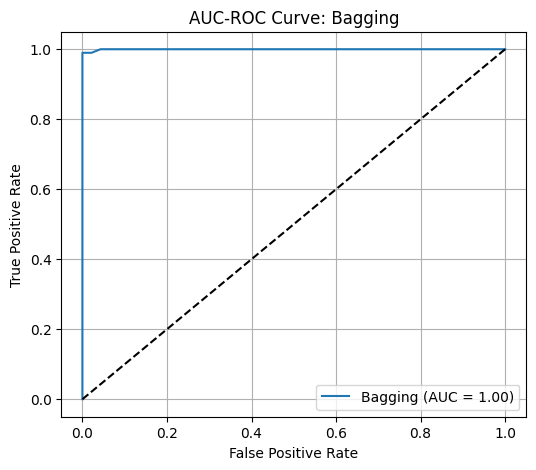

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Bagging (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Bagging')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


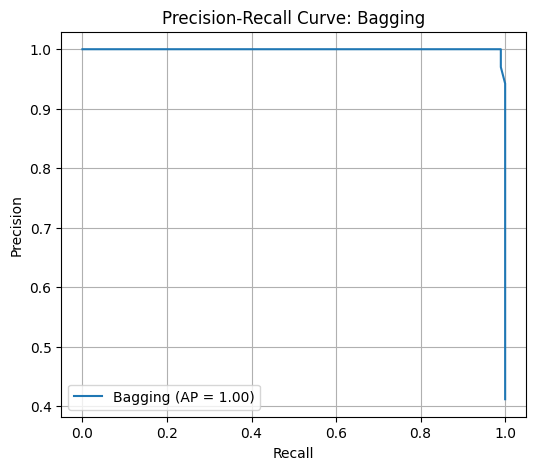

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Bagging (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Bagging')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model8, X_train_selected, y_train, cv=5, scoring='accuracy')
df8 = pd.DataFrame({'CV Score': scores, 'Model': ['Bagging']*len(scores)})


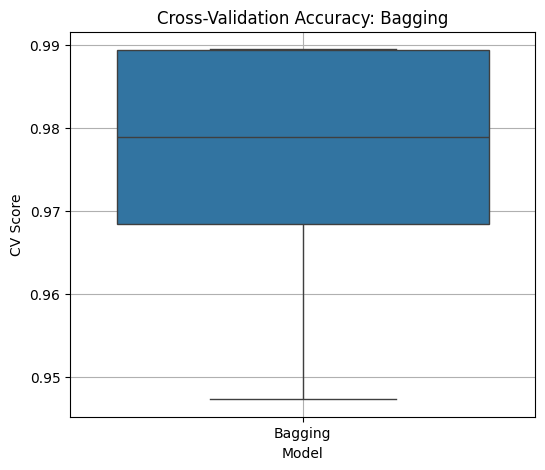

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df8)
plt.title('Cross-Validation Accuracy: Bagging')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model8, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)



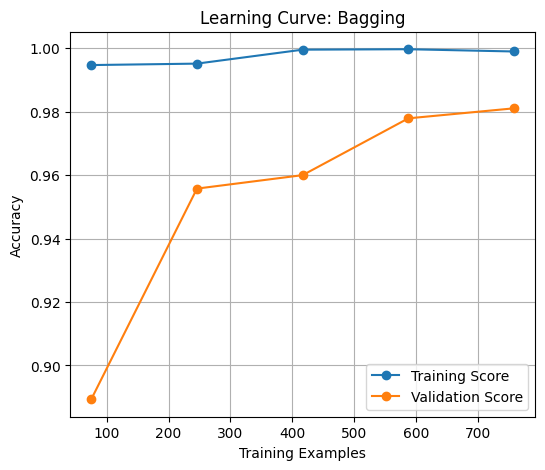

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Bagging')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model9 = KNeighborsClassifier()
model9.fit(X_train_selected, y_train)


KNeighborsClassifier()

In [ ]:
y_pred = model9.predict(X_test_selected)
y_prob=model9.predict_proba(X_test_selected)[:, 1]


In [ ]:
leaderboard.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test,y_prob)
})


In [ ]:
leaderboard[8]

{'Model': 'KNN',
 'Accuracy': 0.9747899159663865,
 'Precision': 0.9791666666666666,
 'Recall': 0.9591836734693877,
 'F1-score': 0.9690721649484536,
 'AUC': np.float64(0.9989795918367347)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



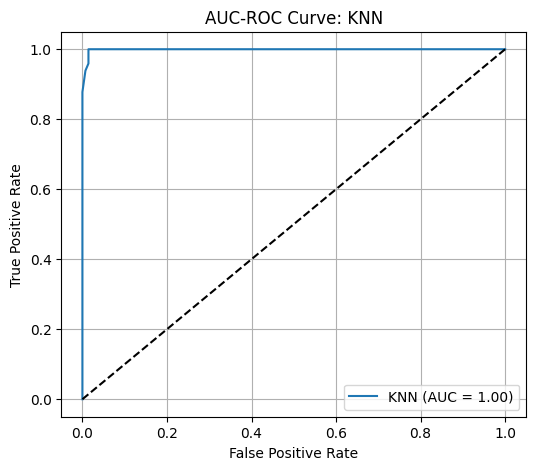

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: KNN')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


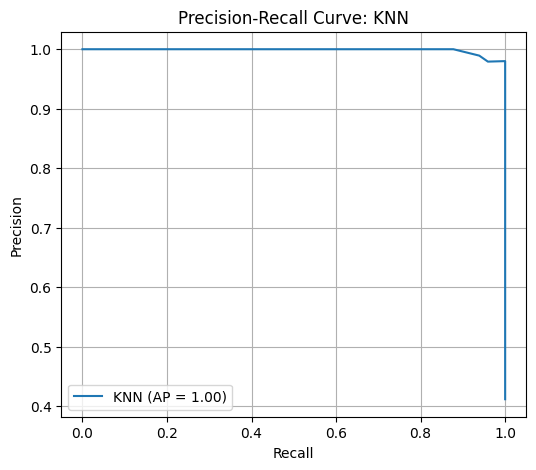

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'KNN (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: KNN')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model9, X_train_selected, y_train, cv=5, scoring='accuracy')
df9 = pd.DataFrame({'CV Score': scores, 'Model': ['KNN']*len(scores)})



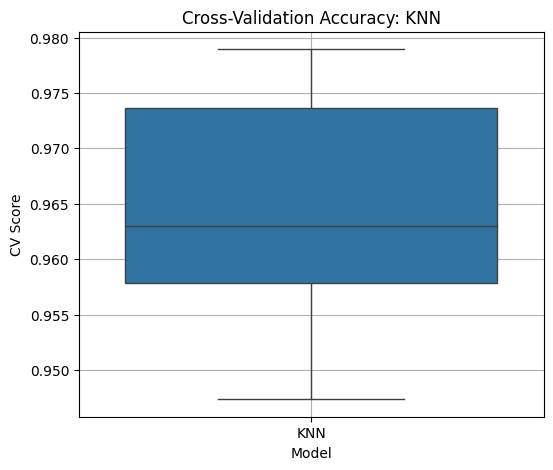

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df9)
plt.title('Cross-Validation Accuracy: KNN')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model9, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


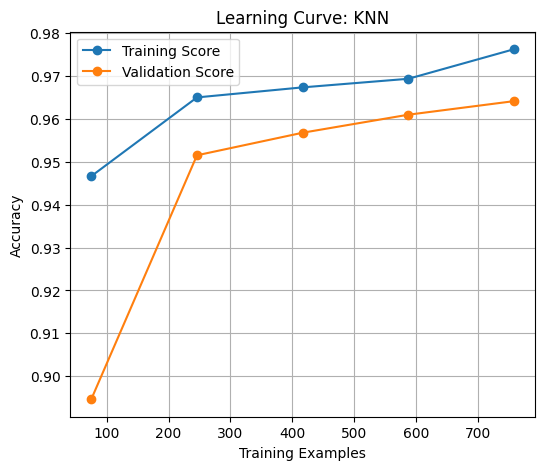

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: KNN')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.naive_bayes import GaussianNB
model10 = GaussianNB()
model10.fit(X_train_selected, y_train)


GaussianNB()

In [ ]:
y_pred = model10.predict(X_test_selected)
y_prob = model10.predict_proba(X_test_selected)[:, 1]


In [ ]:
leaderboard.append({
    'Model': 'Gaussian NB',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[9]

{'Model': 'Gaussian NB',
 'Accuracy': 0.957983193277311,
 'Precision': 0.9888888888888889,
 'Recall': 0.9081632653061225,
 'F1-score': 0.9468085106382979,
 'AUC': np.float64(0.9986880466472303)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



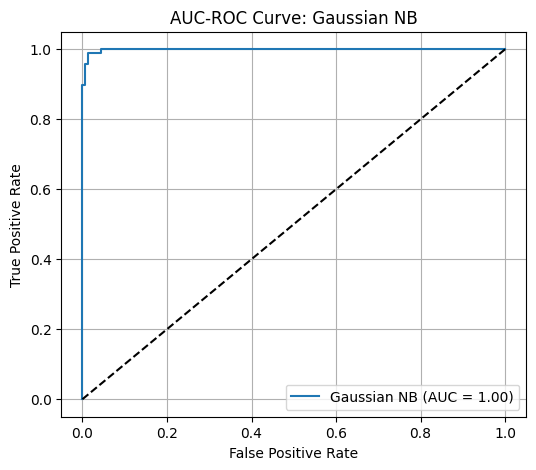

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Gaussian NB (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Gaussian NB')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)



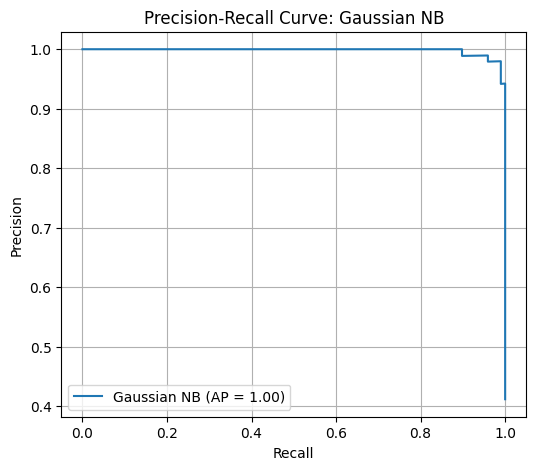

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Gaussian NB (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Gaussian NB')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model10, X_train_selected, y_train, cv=5, scoring='accuracy')
df10 = pd.DataFrame({'CV Score': scores, 'Model': ['Gaussian NB']*len(scores)})


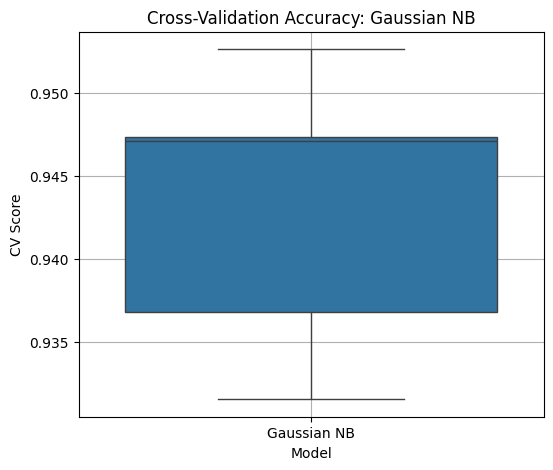

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df10)
plt.title('Cross-Validation Accuracy: Gaussian NB')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model10, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)



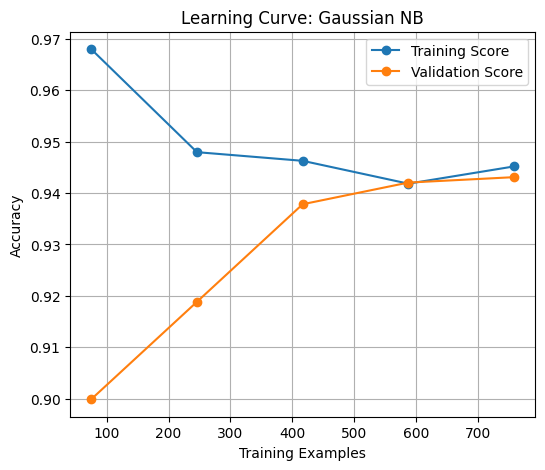

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Gaussian NB')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.naive_bayes import BernoulliNB
model11 = BernoulliNB()
model11.fit(X_train_selected, y_train)


BernoulliNB()

In [ ]:
y_pred = model11.predict(X_test_selected)
y_prob = model11.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'Bernoulli NB',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[10]

{'Model': 'Bernoulli NB',
 'Accuracy': 0.9747899159663865,
 'Precision': 0.9893617021276596,
 'Recall': 0.9489795918367347,
 'F1-score': 0.96875,
 'AUC': np.float64(0.9973396501457725)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)



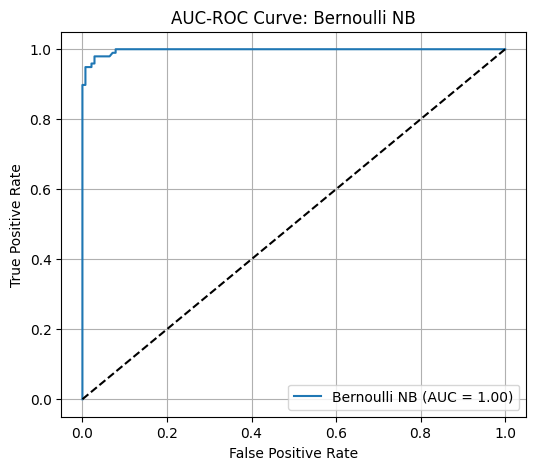

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Bernoulli NB (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Bernoulli NB')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


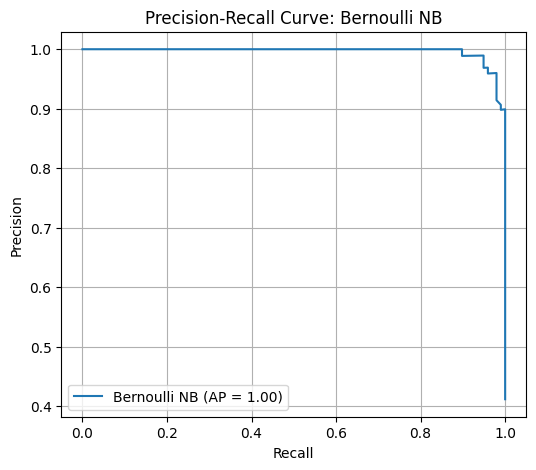

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Bernoulli NB (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Bernoulli NB')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model11, X_train_selected, y_train, cv=5, scoring='accuracy')
df11= pd.DataFrame({'CV Score': scores, 'Model': ['Bernoulli NB']*len(scores)})



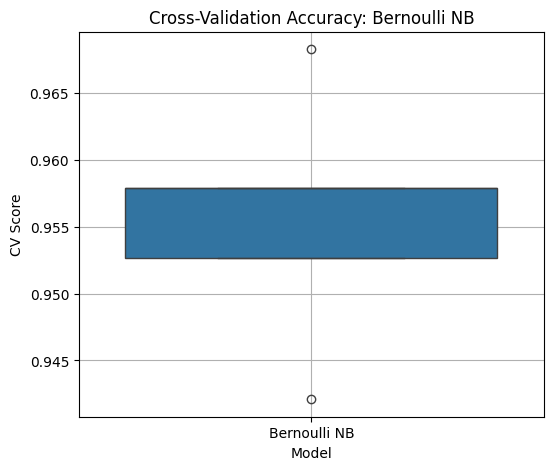

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df11)
plt.title('Cross-Validation Accuracy: Bernoulli NB')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model11, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)



In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


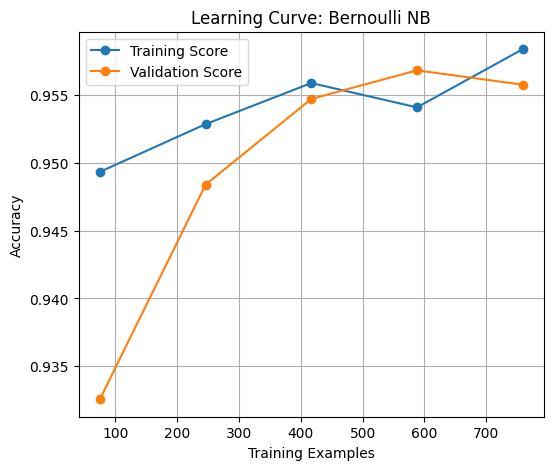

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Bernoulli NB')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.linear_model import RidgeClassifier
model12 = RidgeClassifier()
model12.fit(X_train_selected, y_train)


RidgeClassifier()

In [ ]:
y_pred = model11.predict(X_test_selected)
decision_scores = model12.decision_function(X_test_selected)


In [ ]:
AUC = roc_auc_score(y_test, model.decision_function(X_test_selected))


In [ ]:
leaderboard.append({
    'Model': 'Ridge Classifier',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': AUC
})


In [ ]:
leaderboard[11]

{'Model': 'Ridge Classifier',
 'Accuracy': 0.9747899159663865,
 'Precision': 0.9893617021276596,
 'Recall': 0.9489795918367347,
 'F1-score': 0.96875,
 'AUC': np.float64(0.9995626822157435)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)
    

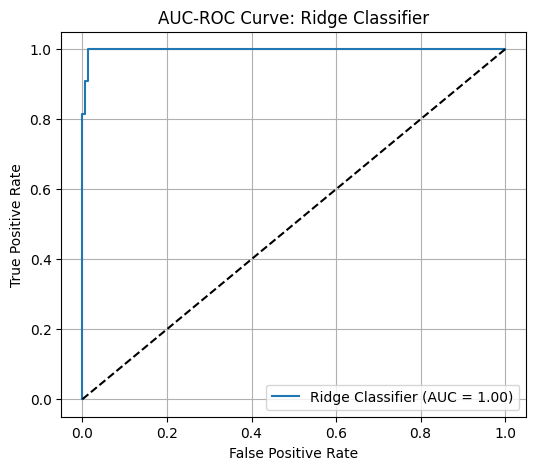

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Ridge Classifier (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Ridge Classifier')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, decision_scores)
avg_precision = average_precision_score(y_test, decision_scores)


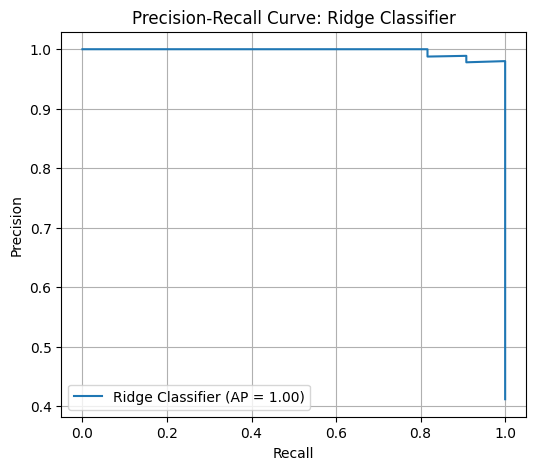

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Ridge Classifier (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Ridge Classifier')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model12, X_train_selected, y_train, cv=5, scoring='accuracy')
df12 = pd.DataFrame({'CV Score': scores, 'Model': ['Ridge Classifier']*len(scores)})



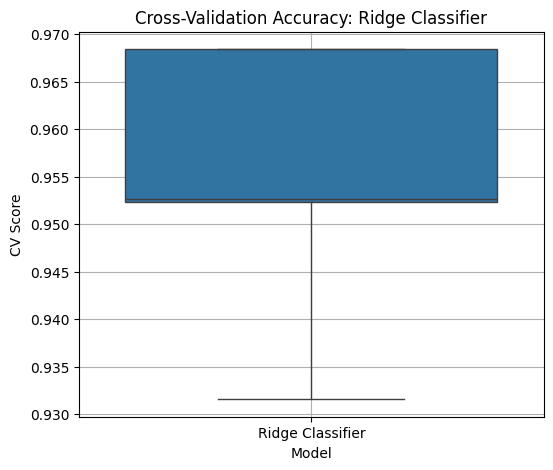

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df12)
plt.title('Cross-Validation Accuracy: Ridge Classifier')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model12, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


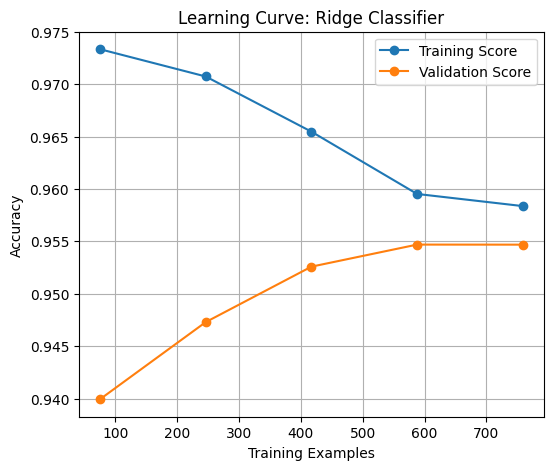

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Ridge Classifier')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
model13 = LinearDiscriminantAnalysis()
model13.fit(X_train_selected, y_train)


LinearDiscriminantAnalysis()

In [ ]:
y_pred = model13.predict(X_test_selected)
y_prob = model13.predict_proba(X_test_selected)[:, 1]


In [ ]:
leaderboard.append({
    'Model': 'Linear Discriminant Analysis',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[12]

{'Model': 'Linear Discriminant Analysis',
 'Accuracy': 0.9705882352941176,
 'Precision': 0.9789473684210527,
 'Recall': 0.9489795918367347,
 'F1-score': 0.9637305699481865,
 'AUC': np.float64(0.9980320699708455)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


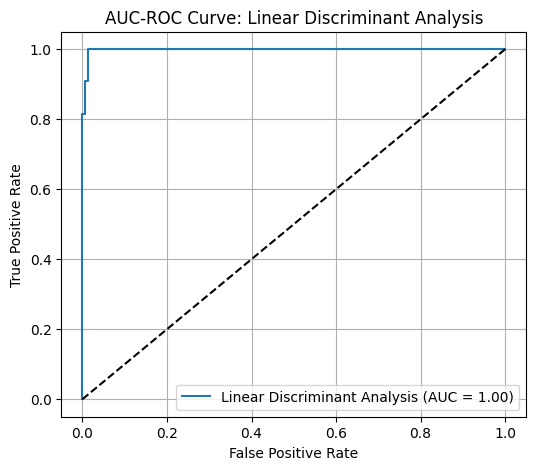

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Linear Discriminant Analysis (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Linear Discriminant Analysis')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


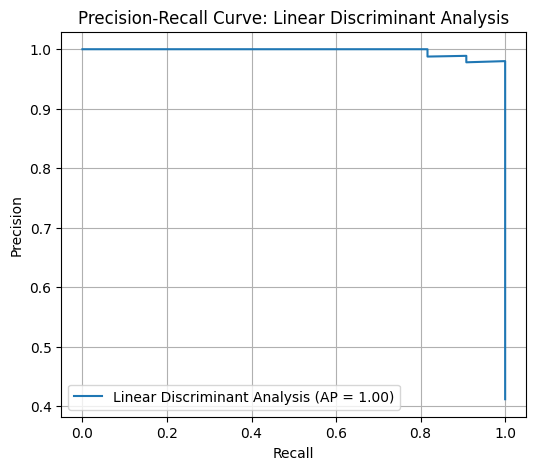

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Linear Discriminant Analysis (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Linear Discriminant Analysis')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model13, X_train_selected, y_train, cv=5, scoring='accuracy')
df13 = pd.DataFrame({'CV Score': scores, 'Model': ['Linear Discriminant Analysis']*len(scores)})


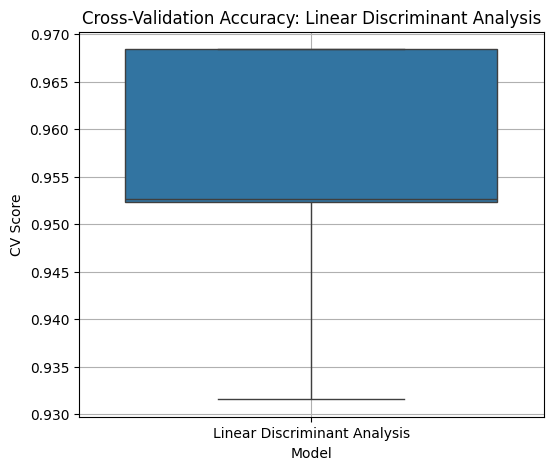

In [ ]:

plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df13)
plt.title('Cross-Validation Accuracy: Linear Discriminant Analysis')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model13, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)



In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)



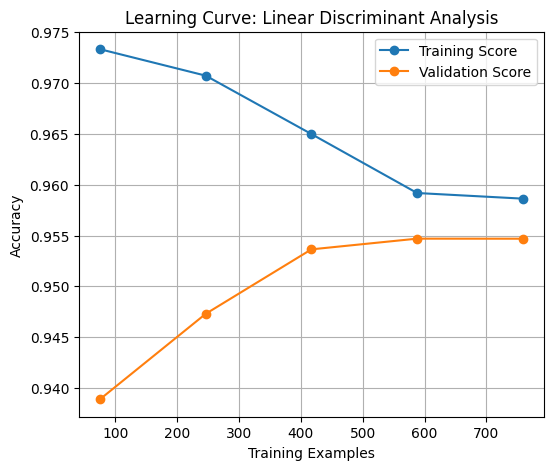

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Linear Discriminant Analysis')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import lightgbm as lgb
model14 = lgb.LGBMClassifier()
model14.fit(X_train_selected, y_train)


[LightGBM] [Info] Number of positive: 376, number of negative: 573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 949, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396207 -> initscore=-0.421297
[LightGBM] [Info] Start training from score -0.421297
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [ ]:
y_pred = model14.predict(X_test_selected)
y_prob = model14.predict_proba(X_test_selected)[:, 1]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:

leaderboard.append({
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[13]

{'Model': 'LightGBM',
 'Accuracy': 0.9915966386554622,
 'Precision': 1.0,
 'Recall': 0.9795918367346939,
 'F1-score': 0.9896907216494846,
 'AUC': np.float64(0.9997813411078716)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


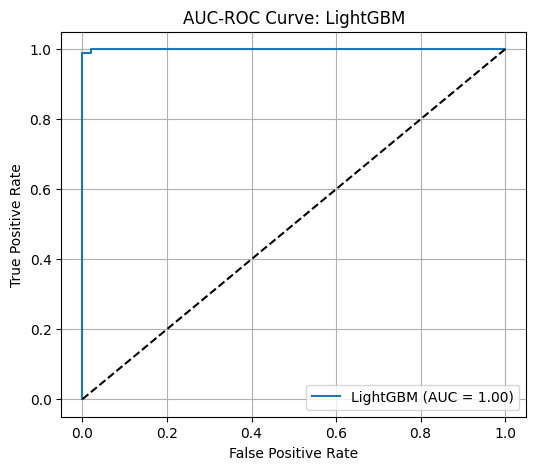

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: LightGBM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


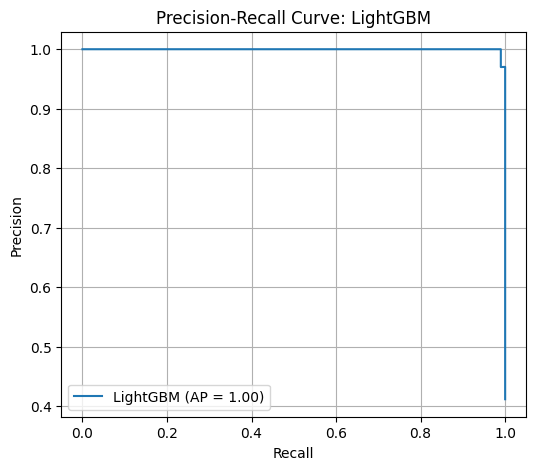

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'LightGBM (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: LightGBM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model14, X_train_selected, y_train, cv=5, scoring='accuracy')
df14 = pd.DataFrame({'CV Score': scores, 'Model': ['LightGBM']*len(scores)})


[LightGBM] [Info] Number of positive: 301, number of negative: 458
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 256
[LightGBM] [Info] Number of data points in the train set: 759, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396574 -> initscore=-0.419759
[LightGBM] [Info] Start training from score -0.419759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 300, number of negative: 459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 759, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.395257 -> initscore=-0.425268
[LightGBM] [Info] Start training from score -0.425268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


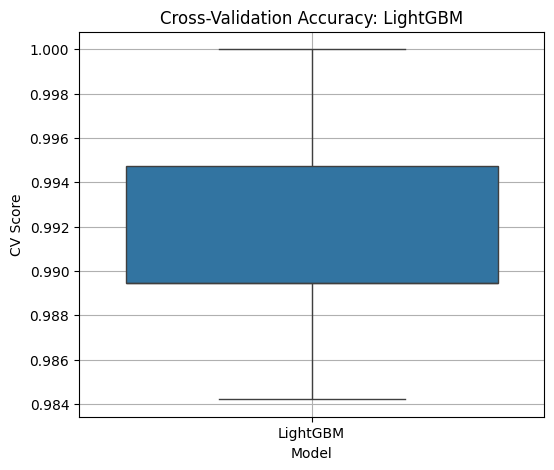

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df14)
plt.title('Cross-Validation Accuracy: LightGBM')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model14, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)



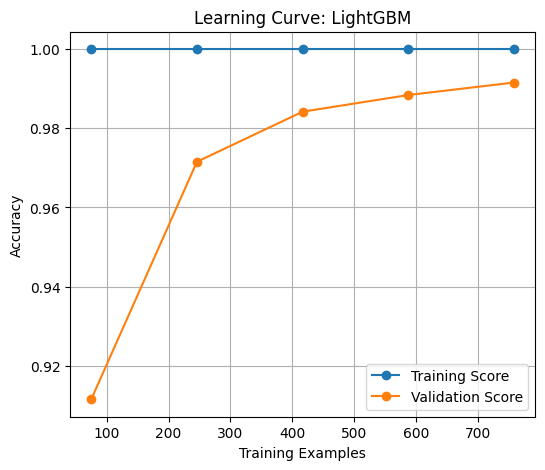

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: LightGBM')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
model15 = ExtraTreesClassifier()
model15.fit(X_train_selected, y_train)


ExtraTreesClassifier()

In [ ]:
y_pred = model15.predict(X_test_selected)
y_prob = model15.predict_proba(X_test_selected)[:, 1]



In [ ]:
leaderboard.append({
    'Model': 'Extra Trees',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
})


In [ ]:
leaderboard[14]

{'Model': 'Extra Trees',
 'Accuracy': 0.9915966386554622,
 'Precision': 0.9897959183673469,
 'Recall': 0.9897959183673469,
 'F1-score': 0.9897959183673469,
 'AUC': np.float64(0.9996355685131195)}

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


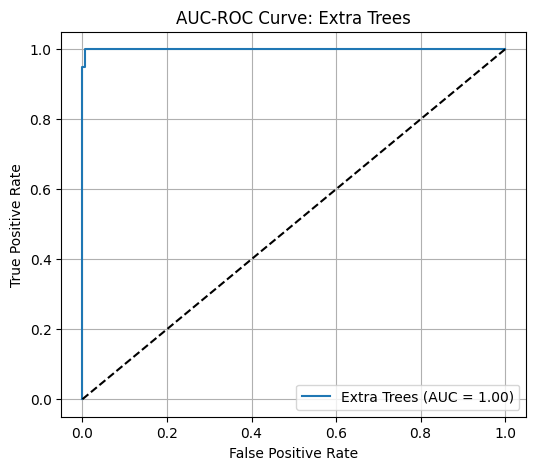

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Extra Trees (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve: Extra Trees')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


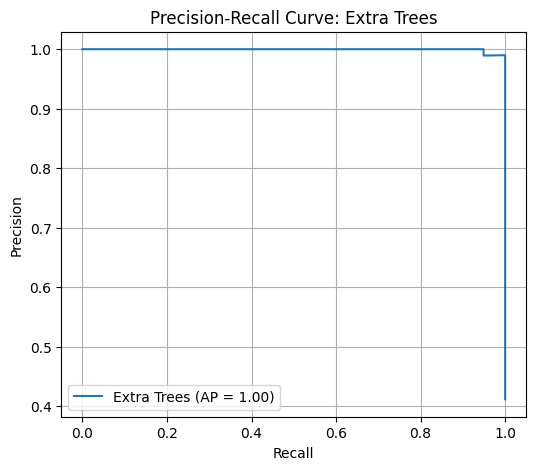

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Extra Trees (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Extra Trees')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
scores = cross_val_score(model15, X_train_selected, y_train, cv=5, scoring='accuracy')
df15 = pd.DataFrame({'CV Score': scores, 'Model': ['Extra Trees']*len(scores)})


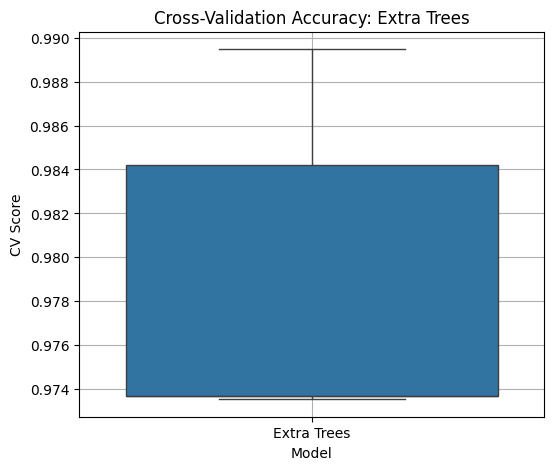

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='CV Score', data=df15)
plt.title('Cross-Validation Accuracy: Extra Trees')
plt.grid(True)
plt.show()


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model15, X_train_selected, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)


In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)



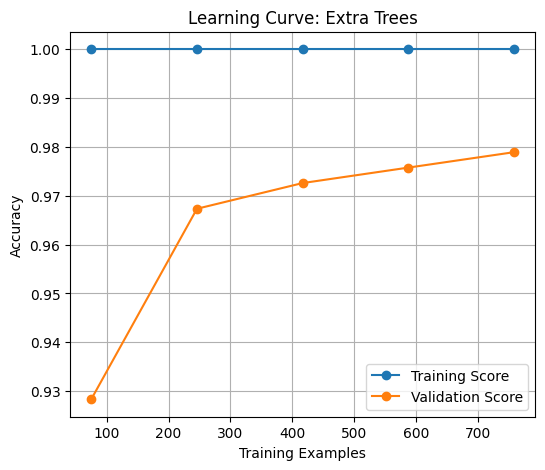

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
plt.title('Learning Curve: Extra Trees')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
leaderboard_df = pd.DataFrame(leaderboard)
leaderboard_df = leaderboard_df.sort_values(by='F1-score', ascending=False)
print("\nModel Performance Leaderboard:")
print(leaderboard_df.reset_index(drop=True))



Model Performance Leaderboard:
                           Model  Accuracy  Precision    Recall  F1-score  \
0                        Bagging  0.995798   1.000000  0.989796  0.994872   
1                    Extra Trees  0.991597   0.989796  0.989796  0.989796   
2                  Random Forest  0.991597   1.000000  0.979592  0.989691   
3                        XGBoost  0.991597   1.000000  0.979592  0.989691   
4                       LightGBM  0.991597   1.000000  0.979592  0.989691   
5                        RBF SVM  0.987395   0.989691  0.979592  0.984615   
6            Logistic Regression  0.987395   0.989691  0.979592  0.984615   
7                Linear SVM (L1)  0.987395   0.989691  0.979592  0.984615   
8                  Decision Tree  0.983193   0.979592  0.979592  0.979592   
9                       AdaBoost  0.983193   0.989583  0.969388  0.979381   
10                           KNN  0.974790   0.979167  0.959184  0.969072   
11              Ridge Classifier  0.974790  

In [ ]:
unique_leaderboard = []
seen_models = set()

for entry in leaderboard:
    model_name = entry['Model']
    if model_name not in seen_models:
        unique_leaderboard.append(entry)
        seen_models.add(model_name)


In [ ]:
leaderboard_df = pd.DataFrame(unique_leaderboard).sort_values(by='F1-score', ascending=False)


In [ ]:
print(leaderboard_df.reset_index(drop=True))


                           Model  Accuracy  Precision    Recall  F1-score  \
0                        Bagging  0.995798   1.000000  0.989796  0.994872   
1                    Extra Trees  0.991597   0.989796  0.989796  0.989796   
2                  Random Forest  0.991597   1.000000  0.979592  0.989691   
3                        XGBoost  0.991597   1.000000  0.979592  0.989691   
4                       LightGBM  0.991597   1.000000  0.979592  0.989691   
5                        RBF SVM  0.987395   0.989691  0.979592  0.984615   
6            Logistic Regression  0.987395   0.989691  0.979592  0.984615   
7                Linear SVM (L1)  0.987395   0.989691  0.979592  0.984615   
8                  Decision Tree  0.983193   0.979592  0.979592  0.979592   
9                       AdaBoost  0.983193   0.989583  0.969388  0.979381   
10                           KNN  0.974790   0.979167  0.959184  0.969072   
11              Ridge Classifier  0.974790   0.989362  0.948980  0.968750   

In [ ]:
leaderboard_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Bagging,0.995798,1.000000,0.989796,0.994872,0.999672
1,Extra Trees,0.991597,0.989796,0.989796,0.989796,0.999636
2,Random Forest,0.991597,1.000000,0.979592,0.989691,0.999490
3,XGBoost,0.991597,1.000000,0.979592,0.989691,1.000000
4,LightGBM,0.991597,1.000000,0.979592,0.989691,0.999781
5,RBF SVM,0.987395,0.989691,0.979592,0.984615,0.999417
6,Logistic Regression,0.987395,0.989691,0.979592,0.984615,0.999563
7,Linear SVM (L1),0.987395,0.989691,0.979592,0.984615,0.999563
8,Decision Tree,0.983193,0.979592,0.979592,0.979592,0.982653
9,AdaBoost,0.983193,0.989583,0.969388,0.979381,0.999781


In [ ]:
leaderboard

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9873949579831933,
  'Precision': 0.9896907216494846,
  'Recall': 0.9795918367346939,
  'F1-score': 0.9846153846153847,
  'AUC': np.float64(0.9995626822157435)},
 {'Model': 'Linear SVM (L1)',
  'Accuracy': 0.9873949579831933,
  'Precision': 0.9896907216494846,
  'Recall': 0.9795918367346939,
  'F1-score': 0.9846153846153847,
  'AUC': np.float64(0.9995626822157435)},
 {'Model': 'RBF SVM',
  'Accuracy': 0.9873949579831933,
  'Precision': 0.9896907216494846,
  'Recall': 0.9795918367346939,
  'F1-score': 0.9846153846153847,
  'AUC': np.float64(0.9994169096209913)},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9831932773109243,
  'Precision': 0.9795918367346939,
  'Recall': 0.9795918367346939,
  'F1-score': 0.9795918367346939,
  'AUC': np.float64(0.9826530612244899)},
 {'Model': 'Random Forest',
  'Accuracy': 0.9915966386554622,
  'Precision': 1.0,
  'Recall': 0.9795918367346939,
  'F1-score': 0.9896907216494846,
  'AUC': np.float64(0.99948979

In [ ]:
df

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,1
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,0
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,0
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,0
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1182,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,1
1183,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,1
1184,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,1
1185,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,1


In [ ]:
df1

,CV Score,Model
0,0.973684,Logistic Regression
1,0.968421,Logistic Regression
2,0.968421,Logistic Regression
3,0.942105,Logistic Regression
4,0.968254,Logistic Regression


In [ ]:
df2

,CV Score,Model
0,0.978947,Linear SVM
1,0.968421,Linear SVM
2,0.963158,Linear SVM
3,0.947368,Linear SVM
4,0.962963,Linear SVM


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline


In [ ]:
models = [
   model,model2,model3,model4,model5,model6,model7,model8,model9,model10,model11,model12,model13,model14,model15
]



In [ ]:
model_names = [
    "Logistic Regression", "Linear SVM (L1)", "RBF SVM", "Decision Tree", "Random Forest", "XGBoost", "AdaBoost", "Bagging", "KNN",
    "Gaussian NB", "Bernoulli NB", "Ridge Classifier", "LDA", "LightGBM", "Extra Trees"]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [22:51:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 376, number of negative: 573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 949, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396207 -> initscore=-0.421297
[LightGBM] [Info] Start training from score -0.421297
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


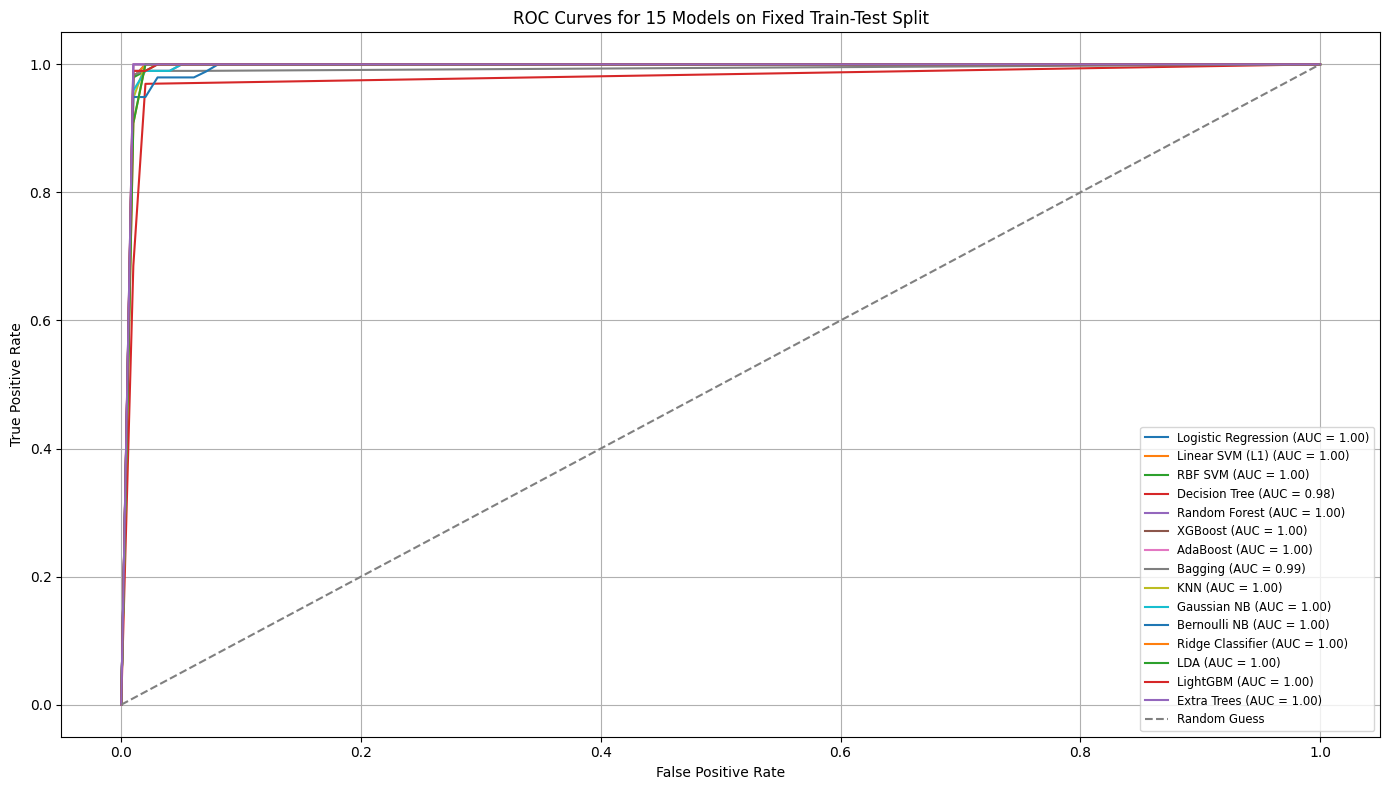

In [ ]:
plt.figure(figsize=(14, 8))
mean_fpr = np.linspace(0, 1, 100)

for Model, name in zip(models, model_names):
    try:
        pipeline = make_pipeline(StandardScaler(), Model)
        pipeline.fit(X_train_selected, y_train)

    
        if hasattr(pipeline, "predict_proba"):
            y_score = pipeline.predict_proba(X_test_selected)[:, 1]
        elif hasattr(pipeline, "decision_function"):
            y_score = pipeline.decision_function(X_test_selected)
        else:
            print(f"Skipping {name}: no probability or decision function")
            continue

       
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

      
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        interp_tpr[-1] = 1.0

        
        plt.plot(mean_fpr, interp_tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    except Exception as e:
        print(f"Skipping {name}: {e}")


plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')


plt.title("ROC Curves for 15 Models on Fixed Train-Test Split")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:00:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 376, number of negative: 573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 949, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396207 -> initscore=-0.421297
[LightGBM] [Info] Start training from score -0.421297
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


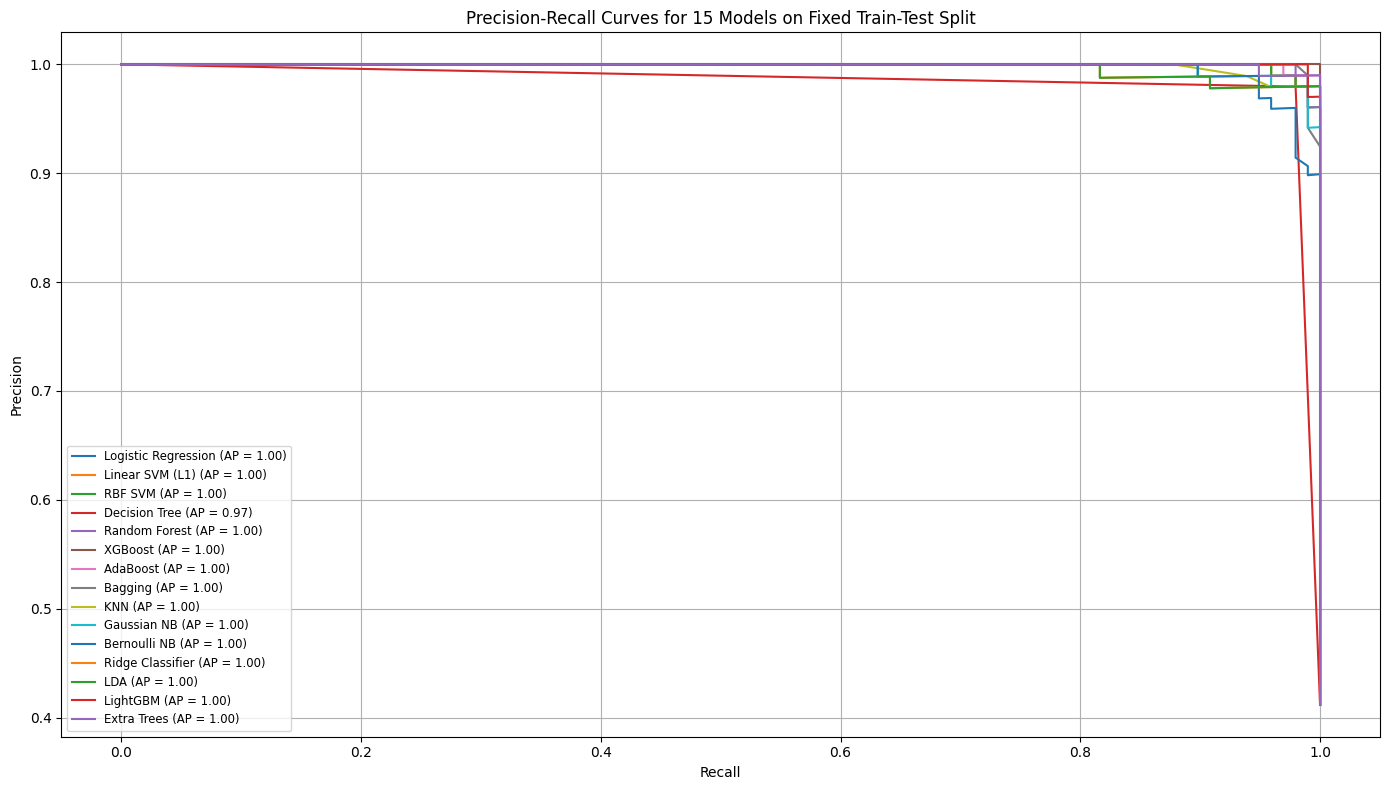

In [ ]:
plt.figure(figsize=(14, 8))

for Model2, name in zip(models, model_names):
    try:
       
        pipeline = make_pipeline(StandardScaler(), Model2)
        pipeline.fit(X_train_selected, y_train)

      
        if hasattr(pipeline, "predict_proba"):
            y_score = pipeline.predict_proba(X_test_selected)[:, 1]
        elif hasattr(pipeline, "decision_function"):
            y_score = pipeline.decision_function(X_test_selected)
        else:
            print(f"Skipping {name}: no probability or decision function")
            continue

       
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        avg_precision = average_precision_score(y_test, y_score)

       
        plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.2f})")
    except Exception as e:
        print(f"Skipping {name}: {e}")


plt.title("Precision-Recall Curves for 15 Models on Fixed Train-Test Split")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.base import clone



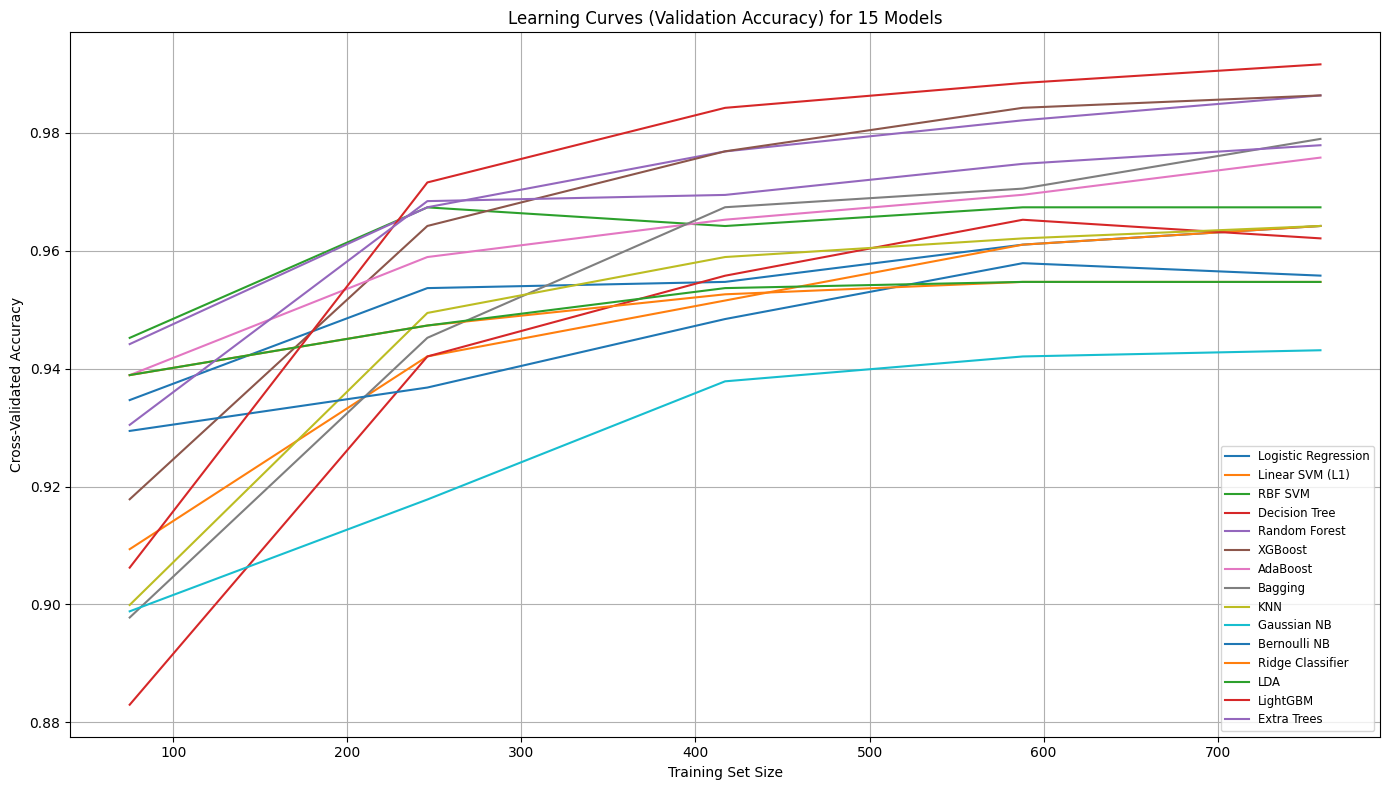

In [ ]:
plt.figure(figsize=(14, 8))


train_sizes = np.linspace(0.1, 1.0, 5)


for Model3, name in zip(models, model_names):
    try:
        # Clone model to avoid contamination
        estimator = make_pipeline(StandardScaler(), clone(Model3))

        # Compute learning curve
        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator, X_train_selected, y_train,
            train_sizes=train_sizes,
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )

        # Compute mean and std
        train_mean = np.mean(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)

        # Plot validation curve
        plt.plot(train_sizes_abs, val_mean, label=f"{name}")
    except Exception as e:
        print(f"Skipping {name}: {e}")

# Final plot settings
plt.title("Learning Curves (Validation Accuracy) for 15 Models")
plt.xlabel("Training Set Size")
plt.ylabel("Cross-Validated Accuracy")
plt.legend(loc="best", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


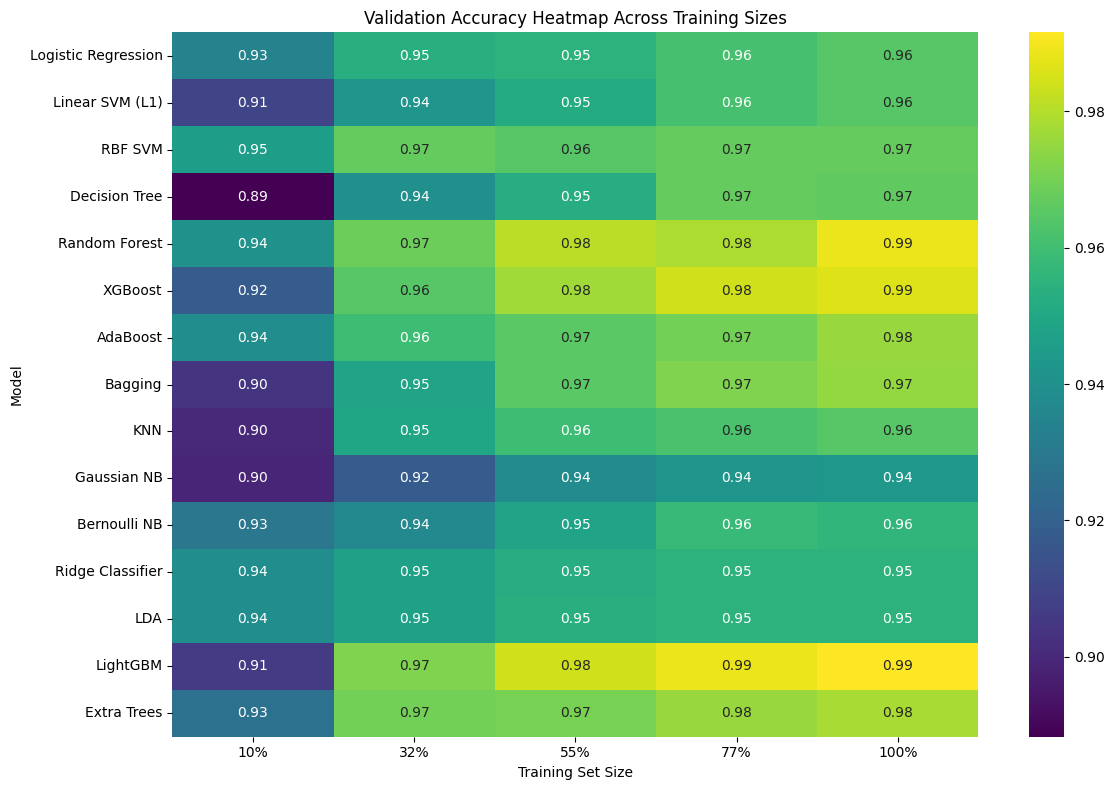

In [ ]:
train_sizes = np.linspace(0.1, 1.0, 5)


val_matrix = []


for Model4, name in zip(models, model_names):
    try:
        estimator = make_pipeline(StandardScaler(), clone(Model4))

        train_sizes_abs, _, val_scores = learning_curve(
            estimator, X_train_selected, y_train,
            train_sizes=train_sizes,
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )

        val_mean = np.mean(val_scores, axis=1)
        val_matrix.append(val_mean)
    except Exception as e:
        print(f"Skipping {name}: {e}")
        val_matrix.append([np.nan] * len(train_sizes))  


val_matrix = np.array(val_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(val_matrix, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[f"{int(s*100)}%" for s in train_sizes],
            yticklabels=model_names)

plt.title("Validation Accuracy Heatmap Across Training Sizes")
plt.xlabel("Training Set Size")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:40:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 376, number of negative: 573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 949, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396207 -> initscore=-0.421297
[LightGBM] [Info] Start training from score -0.421297
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


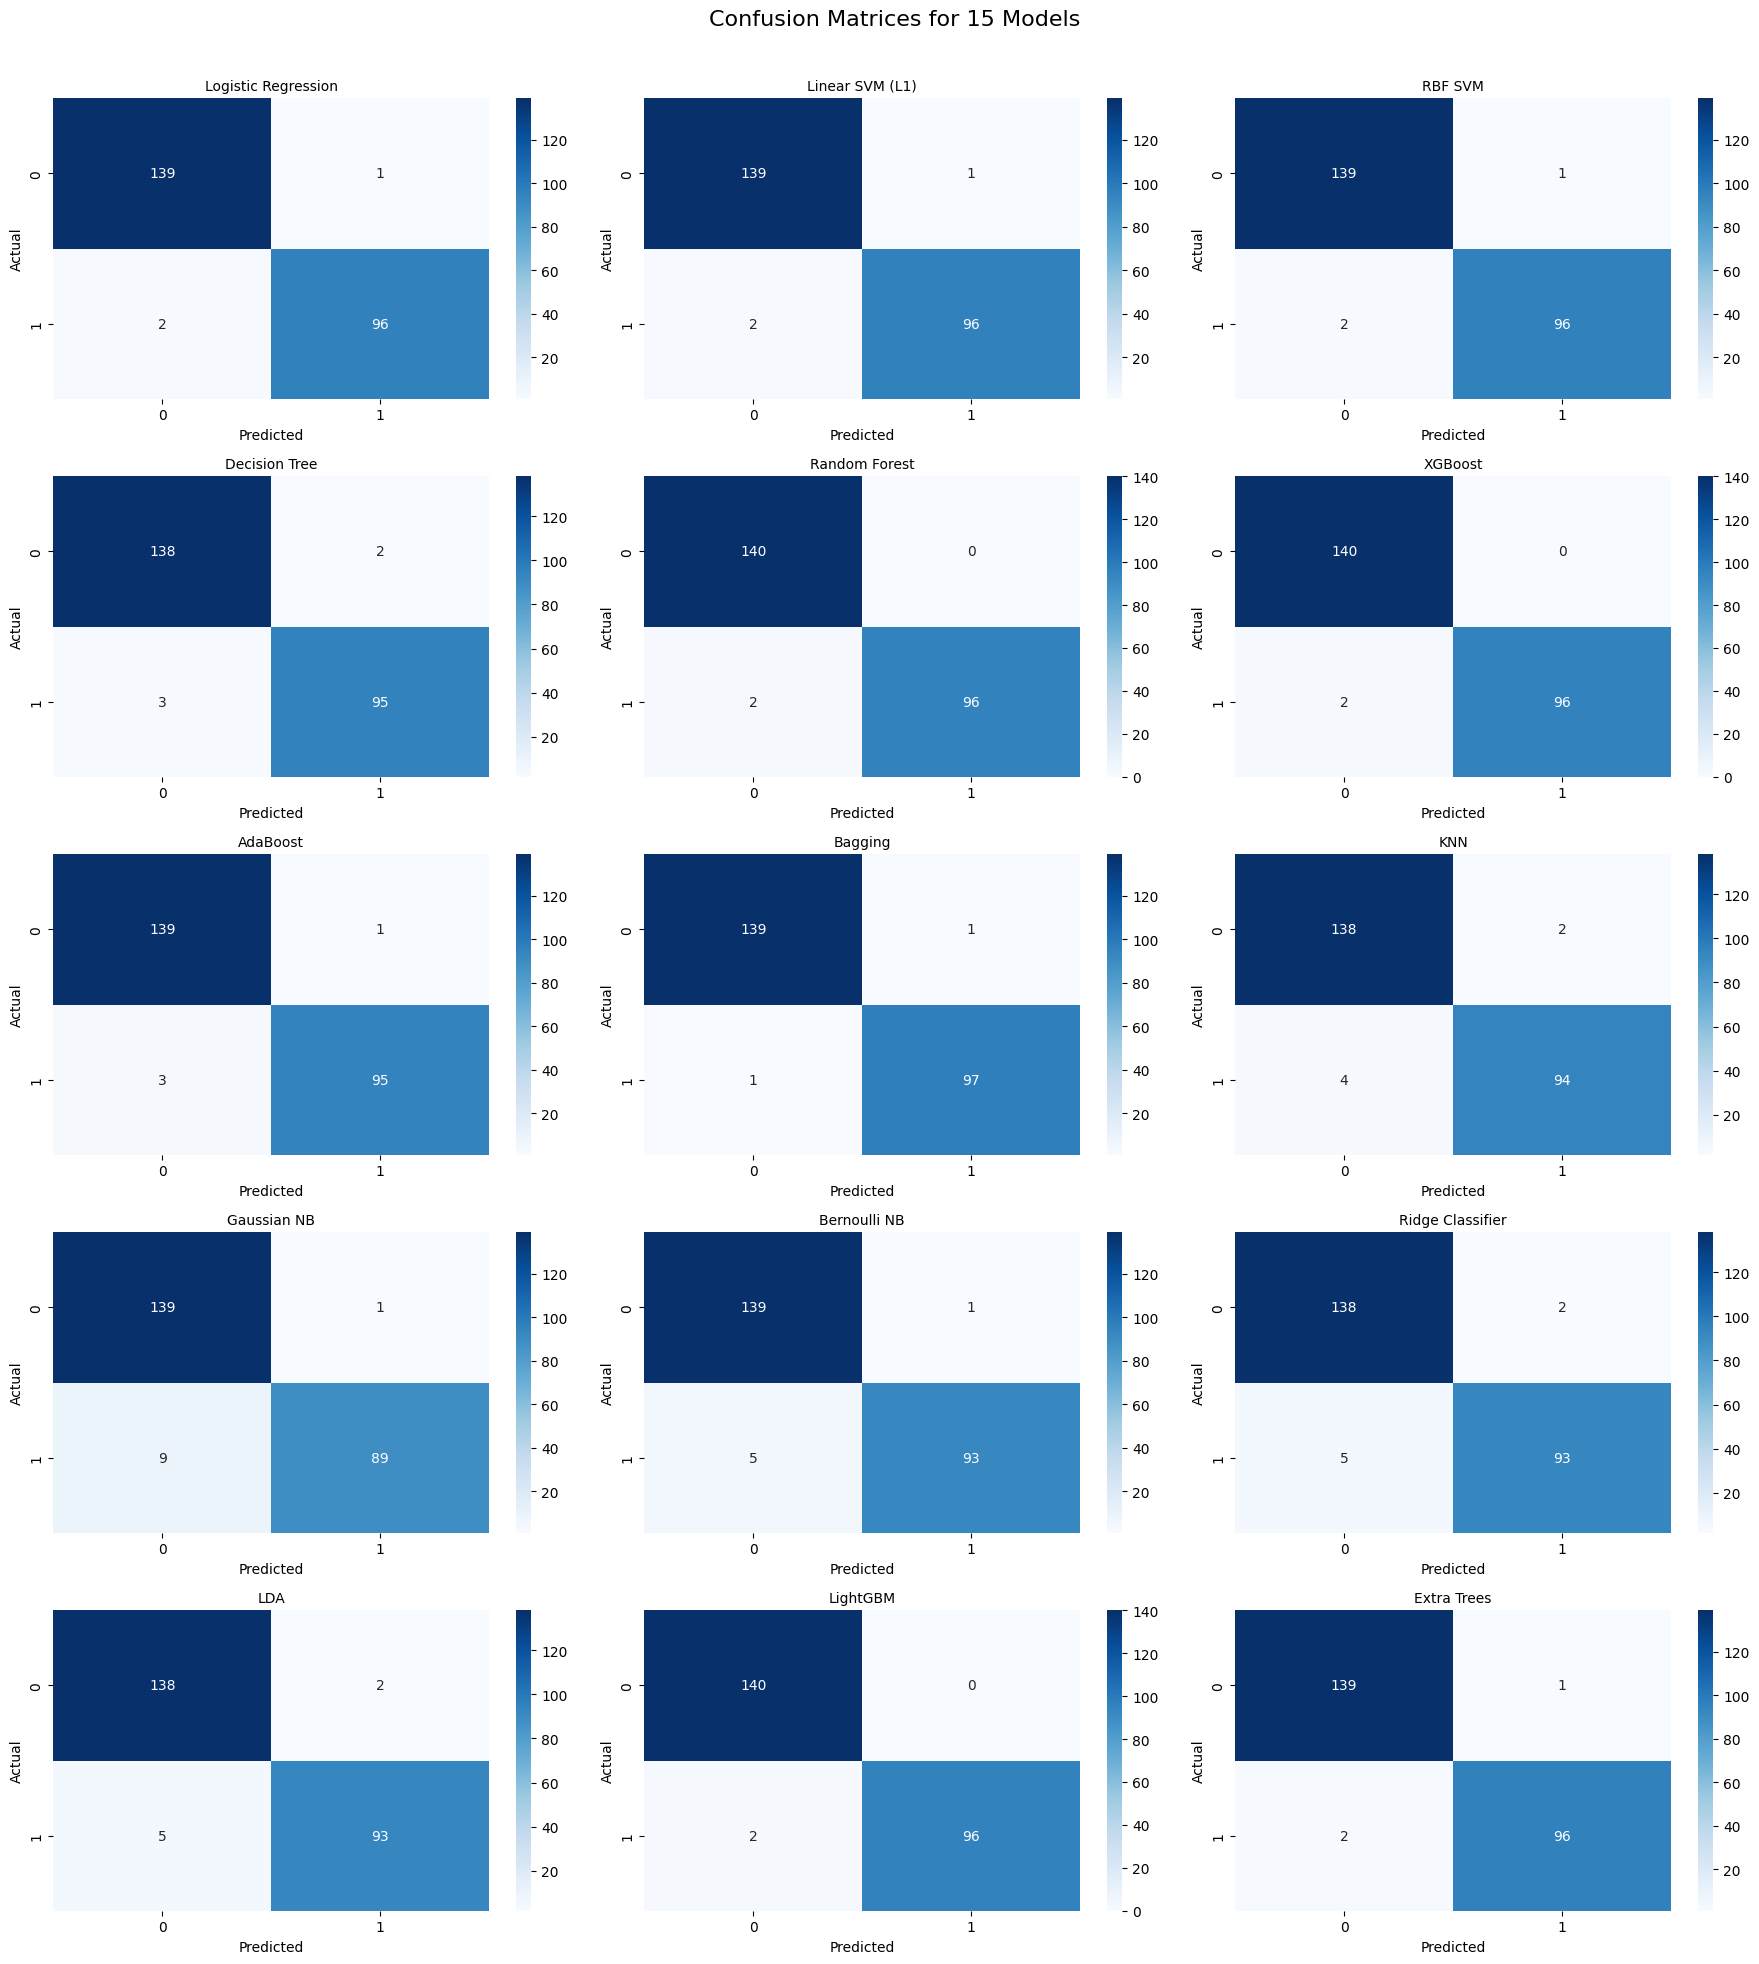

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()


for idx, (Model5, name) in enumerate(zip(models, model_names)):
    try:
        estimator = make_pipeline(StandardScaler(), clone(Model5))
        estimator.fit(X_train_selected, y_train)
        y_pred = estimator.predict(X_test_selected)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx])
        axes[idx].set_title(name, fontsize=10)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    except Exception as e:
        print(f"Skipping {name}: {e}")
        axes[idx].axis('off')  


plt.suptitle("Confusion Matrices for 15 Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
